# 2026-10-08 Six catalogue BPT diagrams by stage

Derived from `20261007_check_NSF_BPT_NII_SII_by_stage_and_galaxy.ipynb`; source unchanged. Show six figures, one for each catalogue selection. Each figure has **3 rows x 2 columns**: pre-peak, close-to-peak, post-peak rows; NII and SII BPT columns. No individual-galaxy figures.

The six overlapping selections are **SF**, **NSF**, **TNSF**, **SF + EW(Halpha)>20**, **NSF + EW(Halpha)<3**, and **TNSF + EW(Halpha)<3**. TNSF is NSF with `NII_BPT == 3` and `SII_BPT` in `{2, 3}` (LINER or Seyfert), including in SII panels. EW cuts are strict and require finite EW.

**Selection:** inherit inclination <80 degrees, unmasked finite-mass/gas-bin disc footprint, finite geometry and mass/gas WCS agreement. Apply finite **`SNR_POSTFIT > 25`**. NSF is the Balmer-detected usable disc outside SF. SF retains finite `LOGSFR_SURFACE_DENSITY_HII`, finite proxy EW(Halpha)>6 Angstrom, and finite intrinsic Halpha dispersion <45 km/s. No extra radius or forbidden-line S/N cut is added; catalogues differ by the stated TNSF class requirements and EW-subset cuts.

**Coordinates:** log10 corrected [NII]6583/Halpha or corrected ([SII]6716+[SII]6730)/Halpha versus corrected [OIII]5006/Hbeta, recomputed from all-region `_FLUX_CORR` maps. Each panel uses a joint finite x/y mask at the same spaxel positions; both SII components must be finite and positive. NII and SII panels can therefore contain different subsets of each catalogue.

**Colour:** absolute spaxel counts per rectangular 2D bin, with zero-count bins masked. Plot styling follows cell 14 of `20260525_initial_further_check.ipynb`: 200 x 200 bins, x=(-2, 0.5), y=(-1.5, 1.5), reference curves, region labels, and a top horizontal colourbar. All stages and catalogues share these bin edges, axis limits and logarithmic count colour normalisation. Bins with fewer than three spaxels are hidden, following the reference minimum-count setting. One colourbar serves all six stage panels in each figure; all six catalogue figures use the same normalisation. Larger footprints contribute more pooled spaxels, and spaxels sharing a gas bin are not independent spectra. No density normalisation is applied. Finite pairs outside the fixed reference plotting window are counted separately and reported. These plots display measured ratios on each catalogue selection, including the joint NII/SII class requirement for TNSF.

Selected-spaxel counts, unavailable-pair counts, outside-window counts and counts hidden by the minimum-bin threshold are printed before each figure. Figures are shown inline with `plt.show()`; no `savefig` calls or FITS writes.


**Population contours:** solid/dashed/dotted black lines enclose approximately 68%/95%/99.7% of each panel's paired selected spaxels. Use the same bin widths as the count map, extend the histogram to include every finite pair, and Gaussian-smooth with sigma=2 bins (0.025 dex in x, 0.030 dex in y). Rank occupied bins by smoothed density, then accumulate their **unsmoothed spaxel counts** to find the density thresholds. Thus fractions refer to the observed spaxel population, rather than fractions of a Gaussian model or confidence intervals. Count thresholding for the background colour map does not affect contour construction. Tied bins can over-enclose the requested fraction; the numerical table reports actual bin-based fractions. Contour interpolation introduces sub-bin boundary differences. Contours can be disconnected and portions outside the fixed BPT window are clipped by the axes, while their populations still enter the denominator. All spaxels have equal weight, including repeated fitted gas bins. Empty panels have no contours. These descriptive contours depend on binning and smoothing; they are not uncertainty estimates.

**TNSF definition update (2026-10-08):** `NSF & (NII_BPT == 3) & np.isin(SII_BPT, [2, 3])`.
SII code 2 is LINER and code 3 is Seyfert; this joint requirement applies
to TNSF and all of its EW-restricted subsets in both BPT diagrams.
The existing SF, NSF, usable-disc footprint, strict SNR_POSTFIT cut,
support rules, and weighting conventions are retained.


In [1]:
from pathlib import Path
import hashlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy import units as u
from IPython.display import display
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "v3tk_v7.6.8").is_dir():
    PROJECT_ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = ("{galid}_gas_bin_maps_further.fits", "{galid}_gas_BIN_maps_further.fits")
EW_FILE_PATTERNS = ("{galid}_proxy_EW_maps_further.fits", "{galid}_proxy_EW_maps.fits")
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"
MASS_HDU, BIN_HDU_MASS, BIN_HDU_GAS = "LOGMASS_SURFACE_DENSITY", "BINID", "BIN_ID"
SFR_HDU, EW_HDU = "LOGSFR_SURFACE_DENSITY_HII", "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU, HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA", "HA6562_SIGMA_CORR"
MASK_TABLE_HDU, MASK_COLUMN = "MASKFILE", "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"
EW_HA_MIN, HALPHA_SIGMA_MAX, SFH_SNR_POSTFIT_MIN = 6.0, 45.0, 25.0
I_MAX_PRIMARY, WCS_TOLERANCE_ARCSEC = 80.0, 0.05
BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = ("BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
                 "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45")
CATEGORY_ORDER = ("SF", "NSF", "TNSF", "SF + EW(Halpha)>20", "NSF + EW(Halpha)<3", "TNSF + EW(Halpha)<3")
N_BPT_BINS = 200
BPT_XLIM = (-2.0, 0.5)
BPT_YLIM = (-1.5, 1.5)
MIN_COUNT_PER_BIN = 3
BPT_CMAP = "viridis"
CONTOUR_FRACTIONS = (0.68, 0.95, 0.997)
CONTOUR_SMOOTH_SIGMA_BINS = 2.0
CONTOUR_STYLES = ("-", "--", ":")
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": False})
SOURCE_NOTEBOOK_SHA256 = "9e9dbf953967918635b4798ea4523433671b7a3b7dfcd71ab7ae9e063abccb7a"
print("Source notebook SHA256:", SOURCE_NOTEBOOK_SHA256)
print("Six catalogue BPT: strict SNR_POSTFIT >25; corrected paired ratios; absolute counts")


Source notebook SHA256: 9e9dbf953967918635b4798ea4523433671b7a3b7dfcd71ab7ae9e063abccb7a
Six catalogue BPT: strict SNR_POSTFIT >25; corrected paired ratios; absolute counts


## Inherited catalogue, geometry and selection helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3) & np.isin(sii, [2, 3])
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    assert np.isin(sii[tnsf], [2, 3]).all()
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii, "sii_bpt_class": sii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": first_existing([folder / MASS_FILE_PATTERN.format(galid=galid)]),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": first_existing([folder / MASK_FILE_PATTERN.format(galid=galid)]),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)



## Load paired ratios for all six catalogue selections and report live QC


In [4]:
def positive_log10(values):
    result = np.full(values.shape, np.nan, dtype=float)
    keep = np.isfinite(values) & (values > 0)
    result[keep] = np.log10(values[keep])
    return result

def corrected_observables(row, shape):
    lines = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730")
    with fits.open(row.sfr_path, memmap=True) as hdul:
        flux = {}
        for line in lines:
            hdu = hdul[line + "_FLUX_CORR"]
            if hdu.data.shape != shape:
                raise ValueError(f"{row.GALID}: corrected {line} shape mismatch")
            if hdu.header.get("BUNIT", "").strip() != "1e-20 erg s-1 cm-2":
                raise ValueError(f"{row.GALID}: unexpected corrected {line} flux unit")
            flux[line] = np.asarray(hdu.data, dtype=float).copy()
        distance = float(hdul[0].header["DIST_MPC"])
        scales = proj_plane_pixel_scales(WCS(hdul[BIN_HDU_GAS].header).celestial)
        if scales.size != 2 or not np.all(np.isfinite(scales) & (scales > 0)) or not (np.isfinite(distance) and distance > 0):
            raise ValueError(f"{row.GALID}: invalid distance or celestial pixel scales")
        area_kpc2 = float(np.prod(np.deg2rad(scales) * distance * 1000))
        distance_cm = (distance * u.Mpc).to_value(u.cm)
        ha_surface = flux["HA6562"] * 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
        provenance = {"DIST_MPC": distance, "pixel_area_kpc2": area_kpc2,
                      "DUSTLAW": hdul[0].header.get("DUSTLAW"), "BPTLIMIT": hdul[0].header.get("BPTLIMIT")}
        # Independent cross-check against the stored corrected luminosity map
        # only on Balmer detections (the stored map substitutes limits elsewhere).
        luminosity = np.asarray(hdul["HALPHA_LUMINOSITY_CORR"].data, dtype=float)
    variables = {"Halpha": positive_log10(ha_surface)}
    flux_to_surface = 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
    variables["OIII5006_SB"] = positive_log10(flux["OIII5006"] * flux_to_surface)
    variables["NII6583_SB"] = positive_log10(flux["NII6583"] * flux_to_surface)
    sii_good = (np.isfinite(flux["SII6716"]) & (flux["SII6716"] > 0)
                & np.isfinite(flux["SII6730"]) & (flux["SII6730"] > 0))
    sii_surface = np.full(shape, np.nan)
    sii_surface[sii_good] = (flux["SII6716"][sii_good] + flux["SII6730"][sii_good]) * flux_to_surface
    variables["SII_SUM_SB"] = positive_log10(sii_surface)
    for key, numerator_lines, denominator in (
        ("O3", ("OIII5006",), "HB4861"),
        ("N2", ("NII6583",), "HA6562"),
        ("S2", ("SII6716", "SII6730"), "HA6562"),
    ):
        good = np.isfinite(flux[denominator]) & (flux[denominator] > 0)
        numerator = np.zeros(shape, dtype=float)
        for line in numerator_lines:
            good &= np.isfinite(flux[line]) & (flux[line] > 0)
            numerator += flux[line]
        ratio = np.full(shape, np.nan)
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            ratio[good] = numerator[good] / flux[denominator][good]
        variables[key] = positive_log10(ratio)
    # Common conversion must cancel in the N2/S2 luminosity surface-density ratios.
    for surface_key, ratio_key in (("NII6583_SB", "N2"), ("SII_SUM_SB", "S2")):
        good = np.isfinite(variables[surface_key]) & np.isfinite(variables["Halpha"])
        assert np.array_equal(good, np.isfinite(variables[ratio_key]))
        assert np.allclose(variables[surface_key][good] - variables["Halpha"][good],
                           variables[ratio_key][good], rtol=0, atol=1e-12)
    return variables, provenance, luminosity, ha_surface * area_kpc2

BPT_BY_GALAXY, qc_rows, count_rows, provenance_rows = [], [], [], []
for row in candidates.itertuples(index=False):
    flags = []
    for label in ("mass", "sfr", "ew", "mask", "sfh"):
        path = getattr(row, label + "_path")
        if not isinstance(path, Path) or not path.exists():
            flags.append("missing_" + label + "_product")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
            sf, nsf, tnsf = (maps[key] & keep for key in ("sf_mask", "nsf_mask", "tnsf_mask"))
            ew = maps["ew_ha"]
            selections = dict(zip(CATEGORY_ORDER, (sf, nsf, tnsf,
                sf & np.isfinite(ew) & (ew > 20),
                nsf & np.isfinite(ew) & (ew < 3),
                tnsf & np.isfinite(ew) & (ew < 3))))
            assert not np.any(sf & nsf)
            assert np.array_equal(tnsf, nsf & (maps["nii_bpt_class"] == 3) & np.isin(maps["sii_bpt_class"], [2, 3]))
            variables, provenance, stored_lum, direct_lum = corrected_observables(row, keep.shape)
            detected = keep & maps["balmer_detected_mask"] & np.isfinite(direct_lum) & (direct_lum > 0)
            if not detected.any() or not np.allclose(stored_lum[detected], direct_lum[detected], rtol=1e-6, atol=0):
                raise ValueError("stored/direct corrected Halpha luminosity disagreement")
            galaxy_counts, galaxy_records = [], []
            for category, selection in selections.items():
                assert not np.any(selection & ~keep)
                record = {"GALID": row.GALID, "stage": row.stage,
                          "category": category, "N_selected": int(selection.sum())}
                for diagram, ratio in (("NII", "N2"), ("SII", "S2")):
                    paired = selection & np.isfinite(variables[ratio]) & np.isfinite(variables["O3"])
                    record[diagram] = np.column_stack((variables[ratio][paired], variables["O3"][paired]))
                    indices = np.flatnonzero(paired)
                    assert np.array_equal(record[diagram][:, 0], variables[ratio].ravel()[indices])
                    assert np.array_equal(record[diagram][:, 1], variables["O3"].ravel()[indices])
                    galaxy_counts.append({"GALID": row.GALID, "stage": row.stage,
                        "category": category, "diagram": diagram,
                        "N_selected": int(selection.sum()), "N_paired": int(paired.sum()),
                        "N_unavailable": int(selection.sum() - paired.sum()),
                        "N_gas_bins": int(np.unique(maps["gas_bin_id"][paired]).size)})
                galaxy_records.append(record)
            BPT_BY_GALAXY.extend(galaxy_records)
            count_rows.extend(galaxy_counts)
            provenance_rows.append({"GALID": row.GALID, "stage": row.stage, **maps["detection_provenance"], **provenance})
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    qc_rows.append({"GALID": row.GALID, "components": row.components, "stage": row.stage,
                    "inclination_deg": row.inclination, "QC_flag": ";".join(flags) if flags else "OK"})

SAMPLE_QC = pd.DataFrame(qc_rows)
BPT_COUNTS = pd.DataFrame(count_rows)
PROVENANCE = pd.DataFrame(provenance_rows)
display(SAMPLE_QC)
display(PROVENANCE)
for stage in STAGE_ORDER:
    ids = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(stage) & SAMPLE_QC.QC_flag.eq("OK"), "GALID"].tolist()
    print(f"{STAGE_LABELS[stage]} ({len(ids)} passing products): {', '.join(ids)}")
    if not ids:
        raise RuntimeError(f"No {stage} products pass QC")
display(BPT_COUNTS)


,GALID,components,stage,inclination_deg,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,OK
5,IC3392,IC3392,post-peak,68.0,OK
6,NGC4064,NGC4064,post-peak,70.0,OK
7,NGC4293,NGC4293,post-peak,67.0,OK
8,NGC4380,NGC4380,post-peak,61.0,OK
9,NGC4394,NGC4394,post-peak,32.0,OK


,GALID,stage,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW,DIST_MPC,pixel_area_kpc2
0,NGC4298,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
1,NGC4424,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
2,NGC4501,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
3,NGC4654,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
4,NGC4694,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
5,IC3392,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
6,NGC4064,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
7,NGC4293,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
8,NGC4380,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
9,NGC4394,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256


Pre-peak (8 passing products): NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8
Close-to-peak (5 passing products): NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Post-peak (13 passing products): IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698


,GALID,stage,category,diagram,N_selected,N_paired,N_unavailable,N_gas_bins
0,NGC4298,close-to-peak,SF,NII,138402,138402,0,8081
1,NGC4298,close-to-peak,SF,SII,138402,138402,0,8081
2,NGC4298,close-to-peak,NSF,NII,43104,42686,418,2822
3,NGC4298,close-to-peak,NSF,SII,43104,42686,418,2822
4,NGC4298,close-to-peak,TNSF,NII,114,114,0,7
...,...,...,...,...,...,...,...,...
307,NGC4567_8,pre-peak,SF + EW(Halpha)>20,SII,92352,92352,0,10438
308,NGC4567_8,pre-peak,NSF + EW(Halpha)<3,NII,6977,6977,0,367
309,NGC4567_8,pre-peak,NSF + EW(Halpha)<3,SII,6977,6977,0,367
310,NGC4567_8,pre-peak,TNSF + EW(Halpha)<3,NII,461,461,0,15


## Reference BPT styling and shared count scale

Follow cell 14 of `20260525_initial_further_check.ipynb`: fixed x/y limits, 200 x 200 bins, minimum three spaxels per displayed bin, Kewley/Kauffmann reference curves and labelled regions. Colour shows counts, with one logarithmic normalization shared across the stage figure and all six catalogue figures. Outside-window pairs and low-count-bin spaxels are reported explicitly.

Population contours use the full paired selected sample independently in each panel; see the first cell for their count-weighted construction. Adjust `CONTOUR_FRACTIONS` and `CONTOUR_SMOOTH_SIGMA_BINS` in the configuration cell.

In [5]:
DIAGRAMS = ("NII", "SII")
def concatenate_pairs(records, diagram):
    arrays = [r[diagram] for r in records]
    return np.concatenate(arrays, axis=0) if arrays else np.empty((0, 2))

# Reference curves and their drawing domains copied from reference cell 14.
def kewley01_N2(x):
    return 0.61 / (x - 0.47) + 1.19

def kauff03_N2(x):
    return 0.61 / (x - 0.05) + 1.30

def kewley01_S2(x):
    return 0.72 / (x - 0.32) + 1.30

def kewley06_Sy_LIN(x):
    return 1.89 * x + 0.76

x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286 - np.sqrt(2871561)) / 1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159 - np.sqrt(105081)) / 525, 0.5, 200)

Y_EDGES = np.linspace(*BPT_YLIM, N_BPT_BINS + 1)
X_EDGES = {d: np.linspace(*BPT_XLIM, N_BPT_BINS + 1) for d in DIAGRAMS}
STAGE_PAIRS = {(category, s, d): concatenate_pairs(
                   [r for r in BPT_BY_GALAXY if r["stage"] == s and r["category"] == category], d)
               for category in CATEGORY_ORDER for s in STAGE_ORDER for d in DIAGRAMS}

def in_bpt_window(pairs):
    return ((pairs[:, 0] >= BPT_XLIM[0]) & (pairs[:, 0] <= BPT_XLIM[1])
            & (pairs[:, 1] >= BPT_YLIM[0]) & (pairs[:, 1] <= BPT_YLIM[1]))

def count_histogram(pairs, diagram):
    counts, _, _ = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=(X_EDGES[diagram], Y_EDGES))
    assert int(counts.sum()) == int(in_bpt_window(pairs).sum())
    return counts

STAGE_HISTOGRAMS = {key: count_histogram(p, key[2]) for key, p in STAGE_PAIRS.items()}
BPT_VMAX = max(MIN_COUNT_PER_BIN + 1, max(int(h.max()) for h in STAGE_HISTOGRAMS.values()))
BPT_NORM = mpl.colors.LogNorm(vmin=MIN_COUNT_PER_BIN, vmax=BPT_VMAX)
print(f"Shared count scale: {MIN_COUNT_PER_BIN} to {BPT_VMAX:,} spaxels/bin (logarithmic)")
print(f"Reference window: x={BPT_XLIM}, y={BPT_YLIM}; {N_BPT_BINS} x {N_BPT_BINS} bins")


def population_contour_grid(pairs):
    """Density-score contours calibrated to raw spaxel counts on a full grid."""
    if not len(pairs):
        return None
    assert np.isfinite(pairs).all()
    dx = (BPT_XLIM[1] - BPT_XLIM[0]) / N_BPT_BINS
    dy = (BPT_YLIM[1] - BPT_YLIM[0]) / N_BPT_BINS
    # Keep bins aligned with the displayed map; pad beyond the full data range.
    padding = int(np.ceil(4 * CONTOUR_SMOOTH_SIGMA_BINS)) + 2
    edges = []
    for dim, step, origin in ((0, dx, BPT_XLIM[0]), (1, dy, BPT_YLIM[0])):
        lower = int(np.floor((pairs[:, dim].min() - origin) / step)) - padding
        upper = int(np.ceil((pairs[:, dim].max() - origin) / step)) + padding + 1
        edges.append(origin + np.arange(lower, upper + 1) * step)
    raw, xe, ye = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=edges)
    assert int(raw.sum()) == len(pairs)
    score = gaussian_filter(raw, sigma=CONTOUR_SMOOTH_SIGMA_BINS, mode='constant', cval=0.0)
    occupied = raw > 0
    density = score[occupied]
    weights = raw[occupied]
    order = np.argsort(density)[::-1]
    cumulative = np.cumsum(weights[order]) / len(pairs)
    levels = []
    for fraction in CONTOUR_FRACTIONS:
        assert 0 < fraction < 1
        index = min(int(np.searchsorted(cumulative, fraction, side='left')), len(order) - 1)
        threshold = float(density[order[index]])
        # Include the threshold bin centres; an isoline is interpolated between centres.
        threshold = np.nextafter(threshold, -np.inf)
        enclosed = float(raw[score >= threshold].sum() / len(pairs))
        strictly_above_tie = float(raw[score > density[order[index]]].sum() / len(pairs))
        assert enclosed + 1e-12 >= fraction
        assert strictly_above_tie <= fraction + 1e-12
        levels.append({'fraction': fraction, 'threshold': threshold,
                       'enclosed_fraction': enclosed, 'fraction_above_tie': strictly_above_tie})
    return (xe[:-1] + np.diff(xe) / 2, ye[:-1] + np.diff(ye) / 2, score.T, levels)

POPULATION_CONTOUR_ROWS = []
def add_population_contours(ax, pairs, diagram, title):
    result = population_contour_grid(pairs)
    if result is None:
        print(f'{title} | {diagram}: no population contours (empty sample)')
        return
    xc, yc, score, levels = result
    handles, seen = [], {}
    for entry, style in zip(levels, CONTOUR_STYLES):
        fraction, threshold = entry['fraction'], entry['threshold']
        label = f'{100 * fraction:g}%'
        # Identical thresholds from tied density scores represent the same boundary.
        if threshold in seen:
            handles[seen[threshold]].set_label(handles[seen[threshold]].get_label() + '/' + label)
        else:
            contour = ax.contour(xc, yc, score, levels=[threshold], colors='black',
                                 linestyles=[style], linewidths=1.6, zorder=12)
            contour.set_path_effects([path_effects.Stroke(linewidth=2.8, foreground='white'),
                                     path_effects.Normal()])
            seen[threshold] = len(handles)
            handles.append(Line2D([], [], color='black', linestyle=style, linewidth=1.6, label=label))
        POPULATION_CONTOUR_ROWS.append({'panel': title, 'diagram': diagram, 'N_paired': len(pairs), **entry})
        print(f'{title} | {diagram}: target={100 * fraction:g}%; enclosed bin-count fraction={entry["enclosed_fraction"]:.4%}')
    ax.legend(handles=handles, title='Enclosed spaxels', loc='upper right', fontsize=10,
              title_fontsize=10, framealpha=0.95).set_zorder(20)


BPT_PLOT_CHECKS, BPT_WINDOW_ROWS = [], []
def draw_bpt_panel(ax, pairs, diagram, title, *, right_panel=False):
    counts = count_histogram(pairs, diagram)
    n_inside = int(counts.sum())
    n_hidden = int(counts[counts < MIN_COUNT_PER_BIN].sum())
    print(f"{title} | {diagram}: paired={len(pairs):,}; inside window={n_inside:,}; "
          f"outside window={len(pairs) - n_inside:,}; hidden in bins <{MIN_COUNT_PER_BIN}={n_hidden:,}")
    mesh = ax.pcolormesh(X_EDGES[diagram], Y_EDGES,
                         np.ma.masked_less(counts.T, MIN_COUNT_PER_BIN),
                         cmap=BPT_CMAP, norm=BPT_NORM, shading="auto",
                         edgecolors="face", linewidths=0, rasterized=True)
    if diagram == "NII":
        ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
        ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)
        regions = ((-1.6, -1.2, 'HII'), (-0.18, -1.3, 'Comp'), (-1.0, 1.0, 'AGN'))
        xlabel = r'$\log([\mathrm{NII}]/\mathrm{H}\alpha)$'
    else:
        ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
        ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)
        regions = ((-1.6, -1.2, 'HII'), (-1.2, 1.0, 'Seyfert'), (0.05, -0.6, 'LINER'))
        xlabel = r'$\log([\mathrm{SII}]/\mathrm{H}\alpha)$'
    add_population_contours(ax, pairs, diagram, title)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('' if right_panel else r'$\log([\mathrm{OIII}]/\mathrm{H}\beta)$', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='y', labelleft=not right_panel)
    ax.set_xlim(BPT_XLIM)
    ax.set_ylim(BPT_YLIM)
    ax.set_title(f"{title} | {diagram} | N={len(pairs):,}", fontsize=17, pad=10)
    for x, y, label in regions:
        ax.text(x, y, label, fontsize=20, fontweight='bold', zorder=11)
    ax.grid(True, alpha=0.3)
    if not np.any(counts >= MIN_COUNT_PER_BIN):
        ax.text(0.5, 0.5, 'No bins above count threshold', ha='center', va='center', transform=ax.transAxes)
    BPT_WINDOW_ROWS.append({"panel": title, "diagram": diagram, "N_paired": len(pairs),
        "N_inside": n_inside, "N_outside": len(pairs) - n_inside, "N_hidden_low_count": n_hidden})
    BPT_PLOT_CHECKS.append(n_inside == int(in_bpt_window(pairs).sum()) and mesh.norm is BPT_NORM
                           and len(ax.lines) == 2 and ax.get_xlim() == BPT_XLIM and ax.get_ylim() == BPT_YLIM)
    return mesh

def top_count_colourbar(fig, mesh, *, stage_figure=False):
    cax = fig.add_axes([0.12, 0.935 if stage_figure else 0.88, 0.76, 0.018 if stage_figure else 0.03])
    cbar = fig.colorbar(mesh, cax=cax, orientation='horizontal')
    cbar.set_label('Spaxels per bin (log colour scale)', fontsize=12, loc='right', labelpad=5)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(labelsize=18)
    return cbar


Shared count scale: 3 to 3,392 spaxels/bin (logarithmic)
Reference window: x=(-2.0, 0.5), y=(-1.5, 1.5); 200 x 200 bins


## Six catalogue BPT figures

One six-panel stage figure per selection, retaining raw spaxel-count colours and population contours. No individual-galaxy plots.


In [6]:
def plot_catalogue_bpt(category):
    fig, axes = plt.subplots(3, 2, figsize=(16, 23), sharey=True)
    fig.subplots_adjust(left=0.09, right=0.97, bottom=0.055, top=0.875, wspace=0.18, hspace=0.27)
    for i, stage in enumerate(STAGE_ORDER):
        rows = BPT_COUNTS.loc[BPT_COUNTS.stage.eq(stage) & BPT_COUNTS.category.eq(category)]
        for j, diagram in enumerate(DIAGRAMS):
            subset = rows.loc[rows.diagram.eq(diagram)]
            contributors = [r for r in BPT_BY_GALAXY if r["stage"] == stage
                            and r["category"] == category and len(r[diagram])]
            print(f"{category} | {STAGE_LABELS[stage]} | {diagram}: selected={subset.N_selected.sum():,}; "
                  f"paired={subset.N_paired.sum():,}; unavailable={subset.N_unavailable.sum():,}; "
                  f"galaxies={len(contributors)}")
            title = category + " | " + STAGE_LABELS[stage]
            mesh = draw_bpt_panel(axes[i, j], STAGE_PAIRS[category, stage, diagram],
                                  diagram, title, right_panel=(j == 1))
    top_count_colourbar(fig, mesh, stage_figure=True)
    fig.suptitle(category + " | corrected BPT ratios | SNR_POSTFIT > 25", fontsize=20, y=0.995)
    assert axes.shape == (3, 2)
    CATALOGUE_PLOT_IDS.append(category)
    plt.show()
    plt.close(fig)

CATALOGUE_PLOT_IDS = []


## SF

Pre-peak, close-to-peak, post-peak rows; NII and SII columns.


SF | Pre-peak | NII: selected=1,420,915; paired=1,420,915; unavailable=0; galaxies=8
SF | Pre-peak | NII: paired=1,420,915; inside window=1,418,389; outside window=2,526; hidden in bins <3=188
SF | Pre-peak | NII: target=68%; enclosed bin-count fraction=68.0229%
SF | Pre-peak | NII: target=95%; enclosed bin-count fraction=95.0122%
SF | Pre-peak | NII: target=99.7%; enclosed bin-count fraction=99.7001%
SF | Pre-peak | SII: selected=1,420,915; paired=1,420,915; unavailable=0; galaxies=8
SF | Pre-peak | SII: paired=1,420,915; inside window=1,418,389; outside window=2,526; hidden in bins <3=466
SF | Pre-peak | SII: target=68%; enclosed bin-count fraction=68.0153%
SF | Pre-peak | SII: target=95%; enclosed bin-count fraction=95.0027%
SF | Pre-peak | SII: target=99.7%; enclosed bin-count fraction=99.7002%
SF | Close-to-peak | NII: selected=720,842; paired=720,842; unavailable=0; galaxies=5
SF | Close-to-peak | NII: paired=720,842; inside window=720,447; outside window=395; hidden in bins <3=1

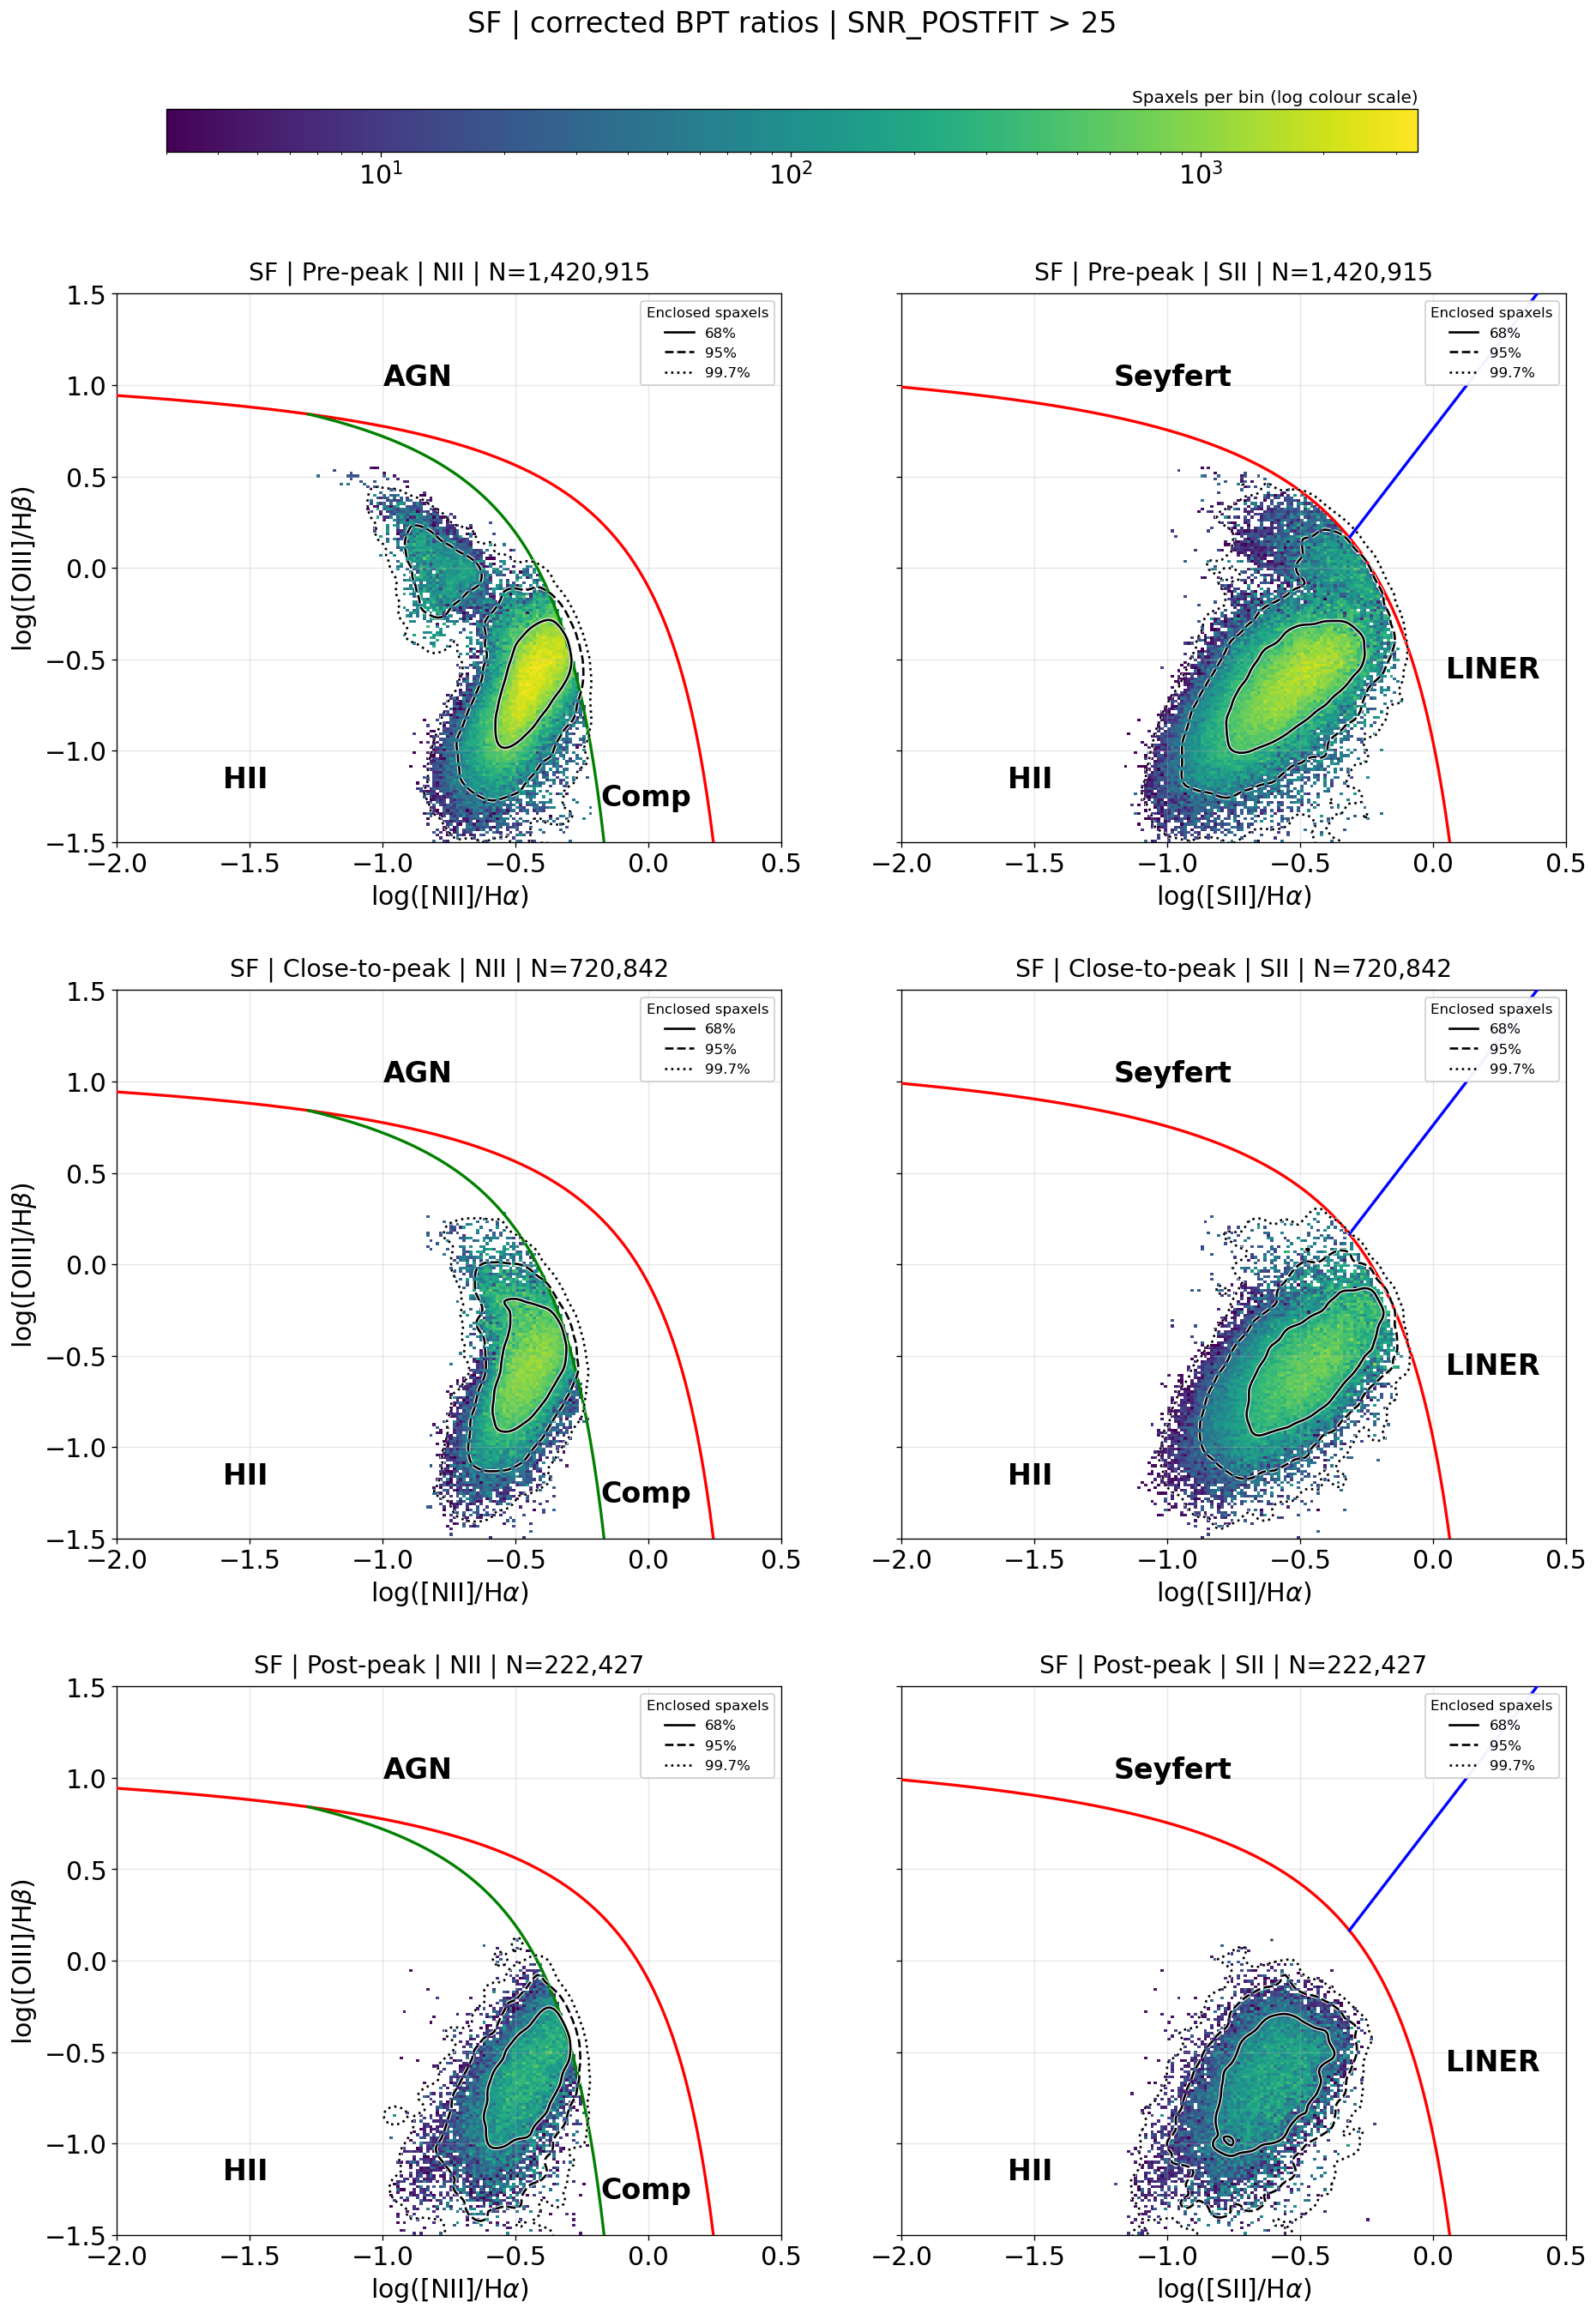

In [7]:
plot_catalogue_bpt('SF')


## NSF

Pre-peak, close-to-peak, post-peak rows; NII and SII columns.


NSF | Pre-peak | NII: selected=929,104; paired=923,230; unavailable=5,874; galaxies=8
NSF | Pre-peak | NII: paired=923,230; inside window=922,677; outside window=553; hidden in bins <3=561
NSF | Pre-peak | NII: target=68%; enclosed bin-count fraction=68.0026%
NSF | Pre-peak | NII: target=95%; enclosed bin-count fraction=95.0024%
NSF | Pre-peak | NII: target=99.7%; enclosed bin-count fraction=99.7002%
NSF | Pre-peak | SII: selected=929,104; paired=923,217; unavailable=5,887; galaxies=8
NSF | Pre-peak | SII: paired=923,217; inside window=922,664; outside window=553; hidden in bins <3=1,054
NSF | Pre-peak | SII: target=68%; enclosed bin-count fraction=68.0164%
NSF | Pre-peak | SII: target=95%; enclosed bin-count fraction=95.0104%
NSF | Pre-peak | SII: target=99.7%; enclosed bin-count fraction=99.7009%
NSF | Close-to-peak | NII: selected=488,865; paired=486,897; unavailable=1,968; galaxies=5
NSF | Close-to-peak | NII: paired=486,897; inside window=486,658; outside window=239; hidden in bin

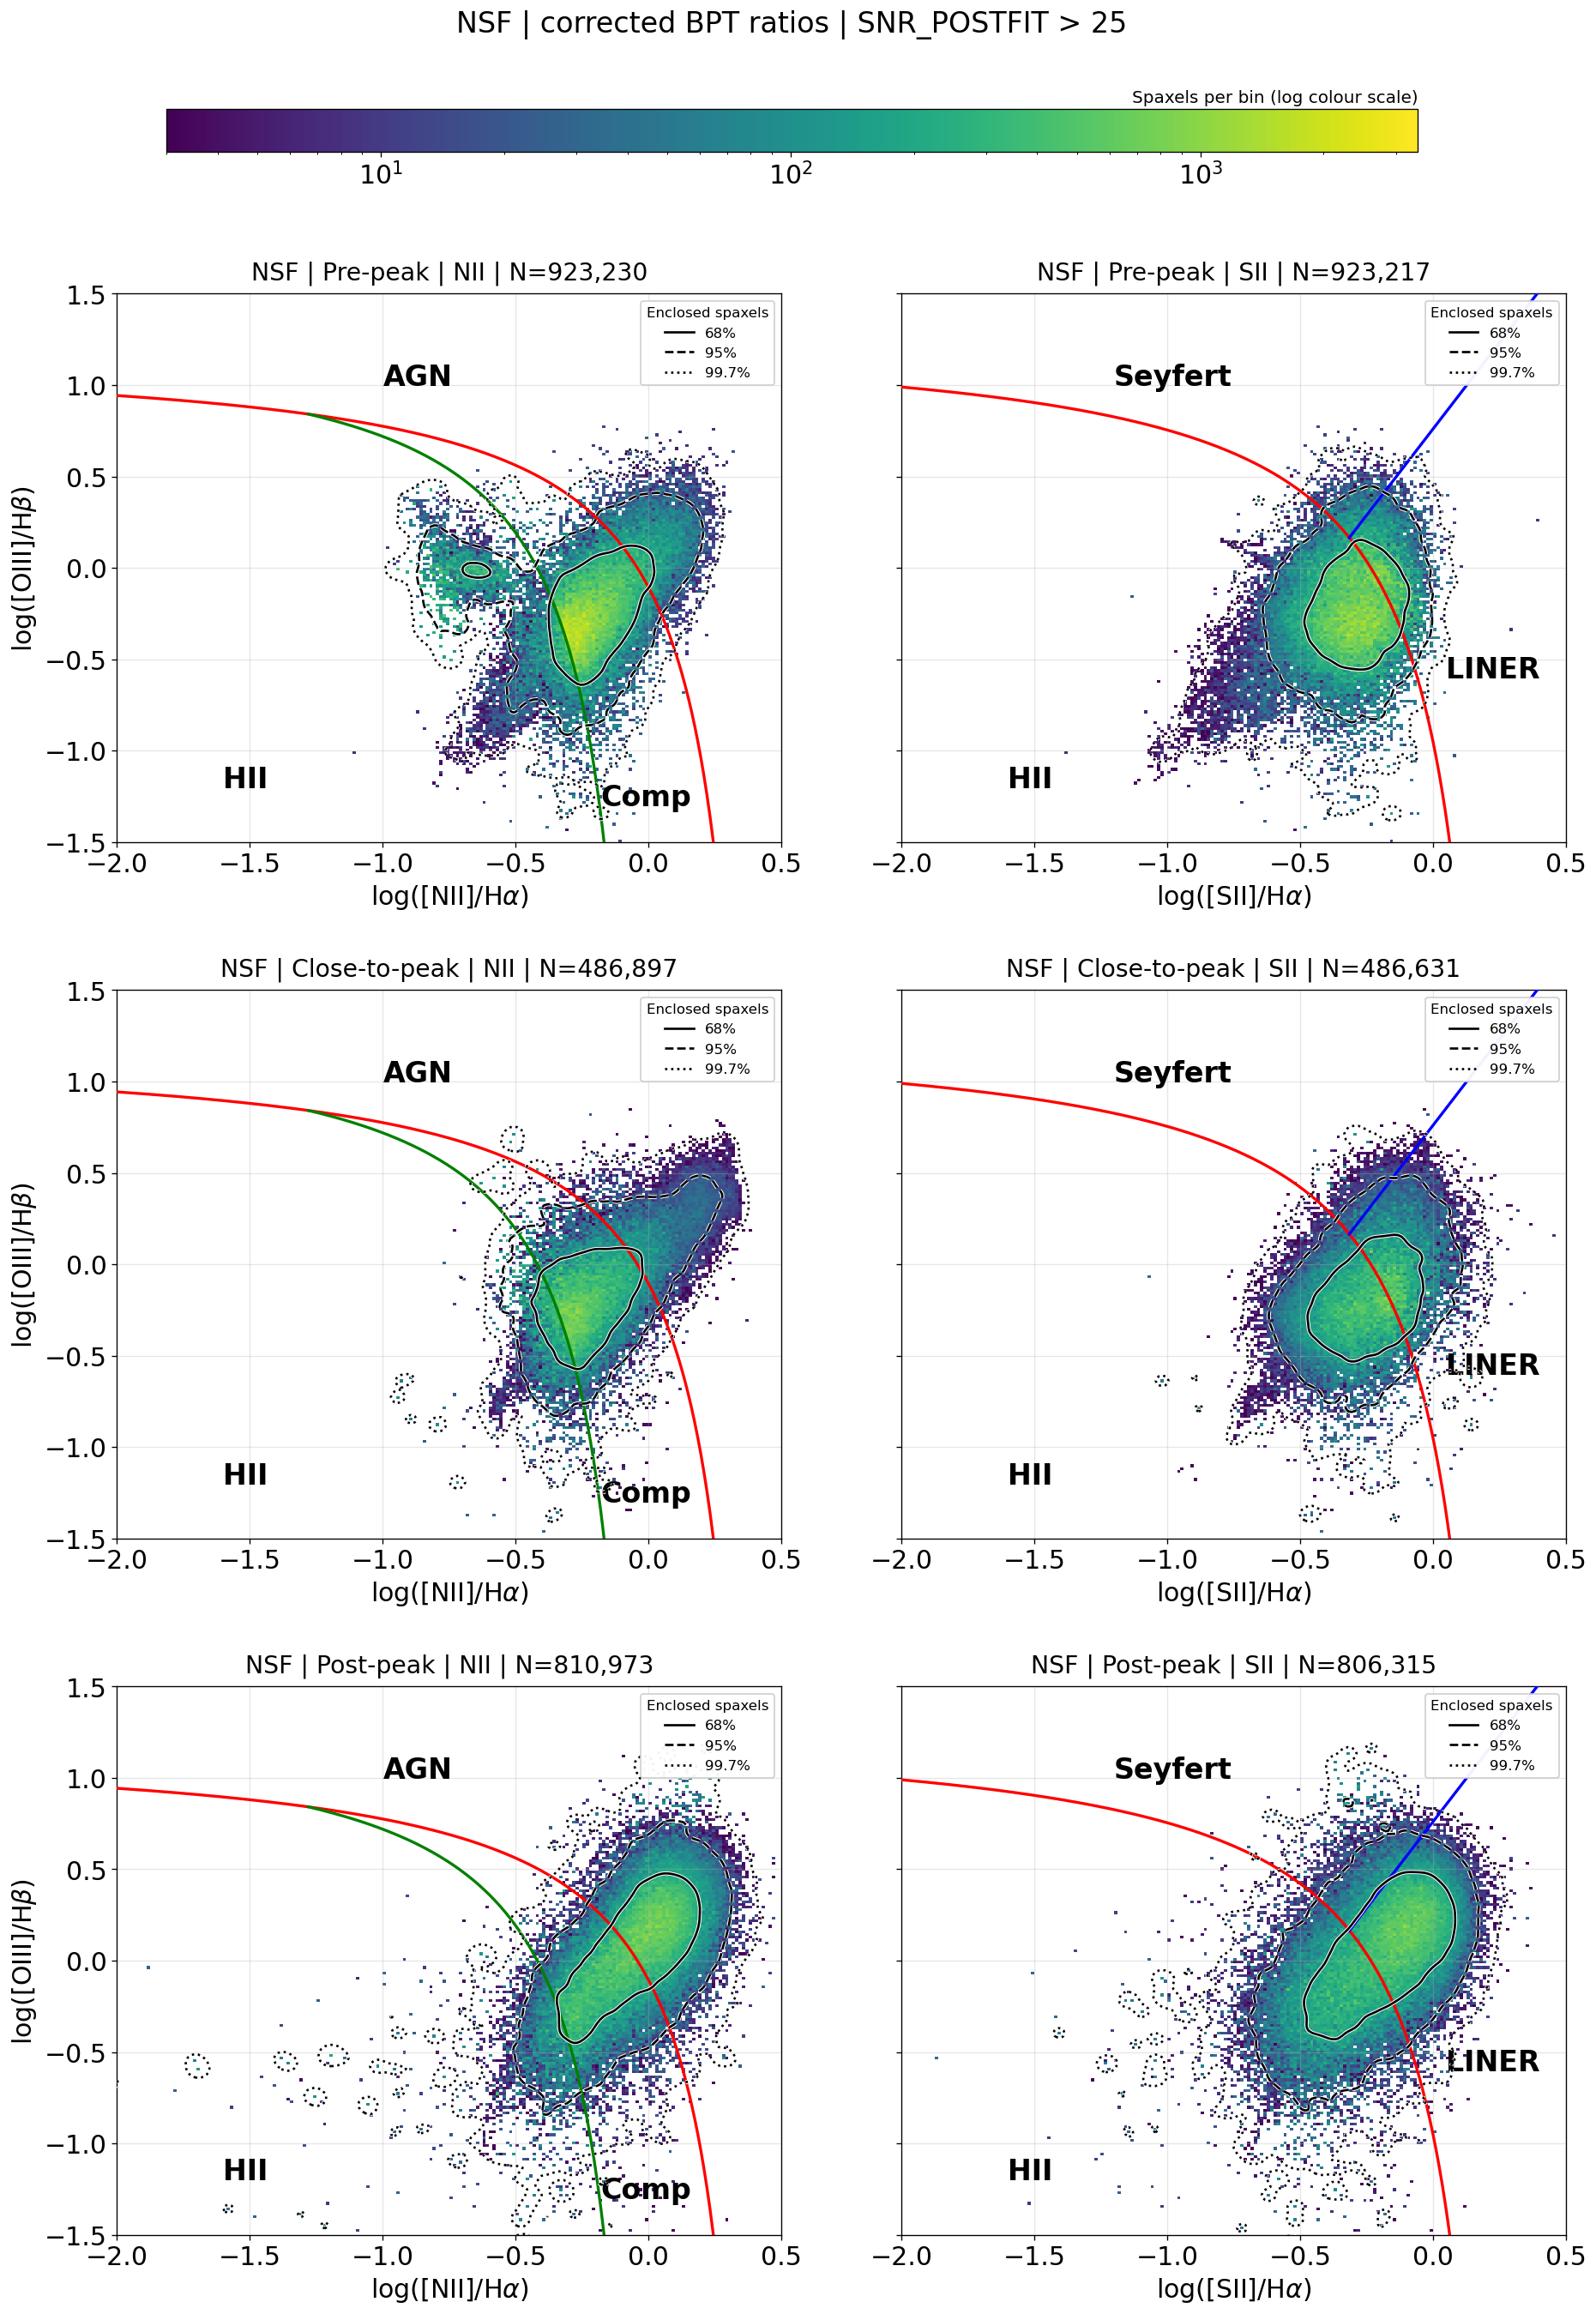

In [8]:
plot_catalogue_bpt('NSF')


## TNSF

Pre-peak, close-to-peak, post-peak rows; NII and SII columns.


TNSF | Pre-peak | NII: selected=8,852; paired=8,852; unavailable=0; galaxies=5
TNSF | Pre-peak | NII: paired=8,852; inside window=8,852; outside window=0; hidden in bins <3=64
TNSF | Pre-peak | NII: target=68%; enclosed bin-count fraction=68.2332%
TNSF | Pre-peak | NII: target=95%; enclosed bin-count fraction=95.1423%
TNSF | Pre-peak | NII: target=99.7%; enclosed bin-count fraction=99.7402%
TNSF | Pre-peak | SII: selected=8,852; paired=8,852; unavailable=0; galaxies=5
TNSF | Pre-peak | SII: paired=8,852; inside window=8,852; outside window=0; hidden in bins <3=66
TNSF | Pre-peak | SII: target=68%; enclosed bin-count fraction=68.1315%
TNSF | Pre-peak | SII: target=95%; enclosed bin-count fraction=95.0520%
TNSF | Pre-peak | SII: target=99.7%; enclosed bin-count fraction=99.7176%
TNSF | Close-to-peak | NII: selected=6,217; paired=6,217; unavailable=0; galaxies=5
TNSF | Close-to-peak | NII: paired=6,217; inside window=6,217; outside window=0; hidden in bins <3=277
TNSF | Close-to-peak | NI

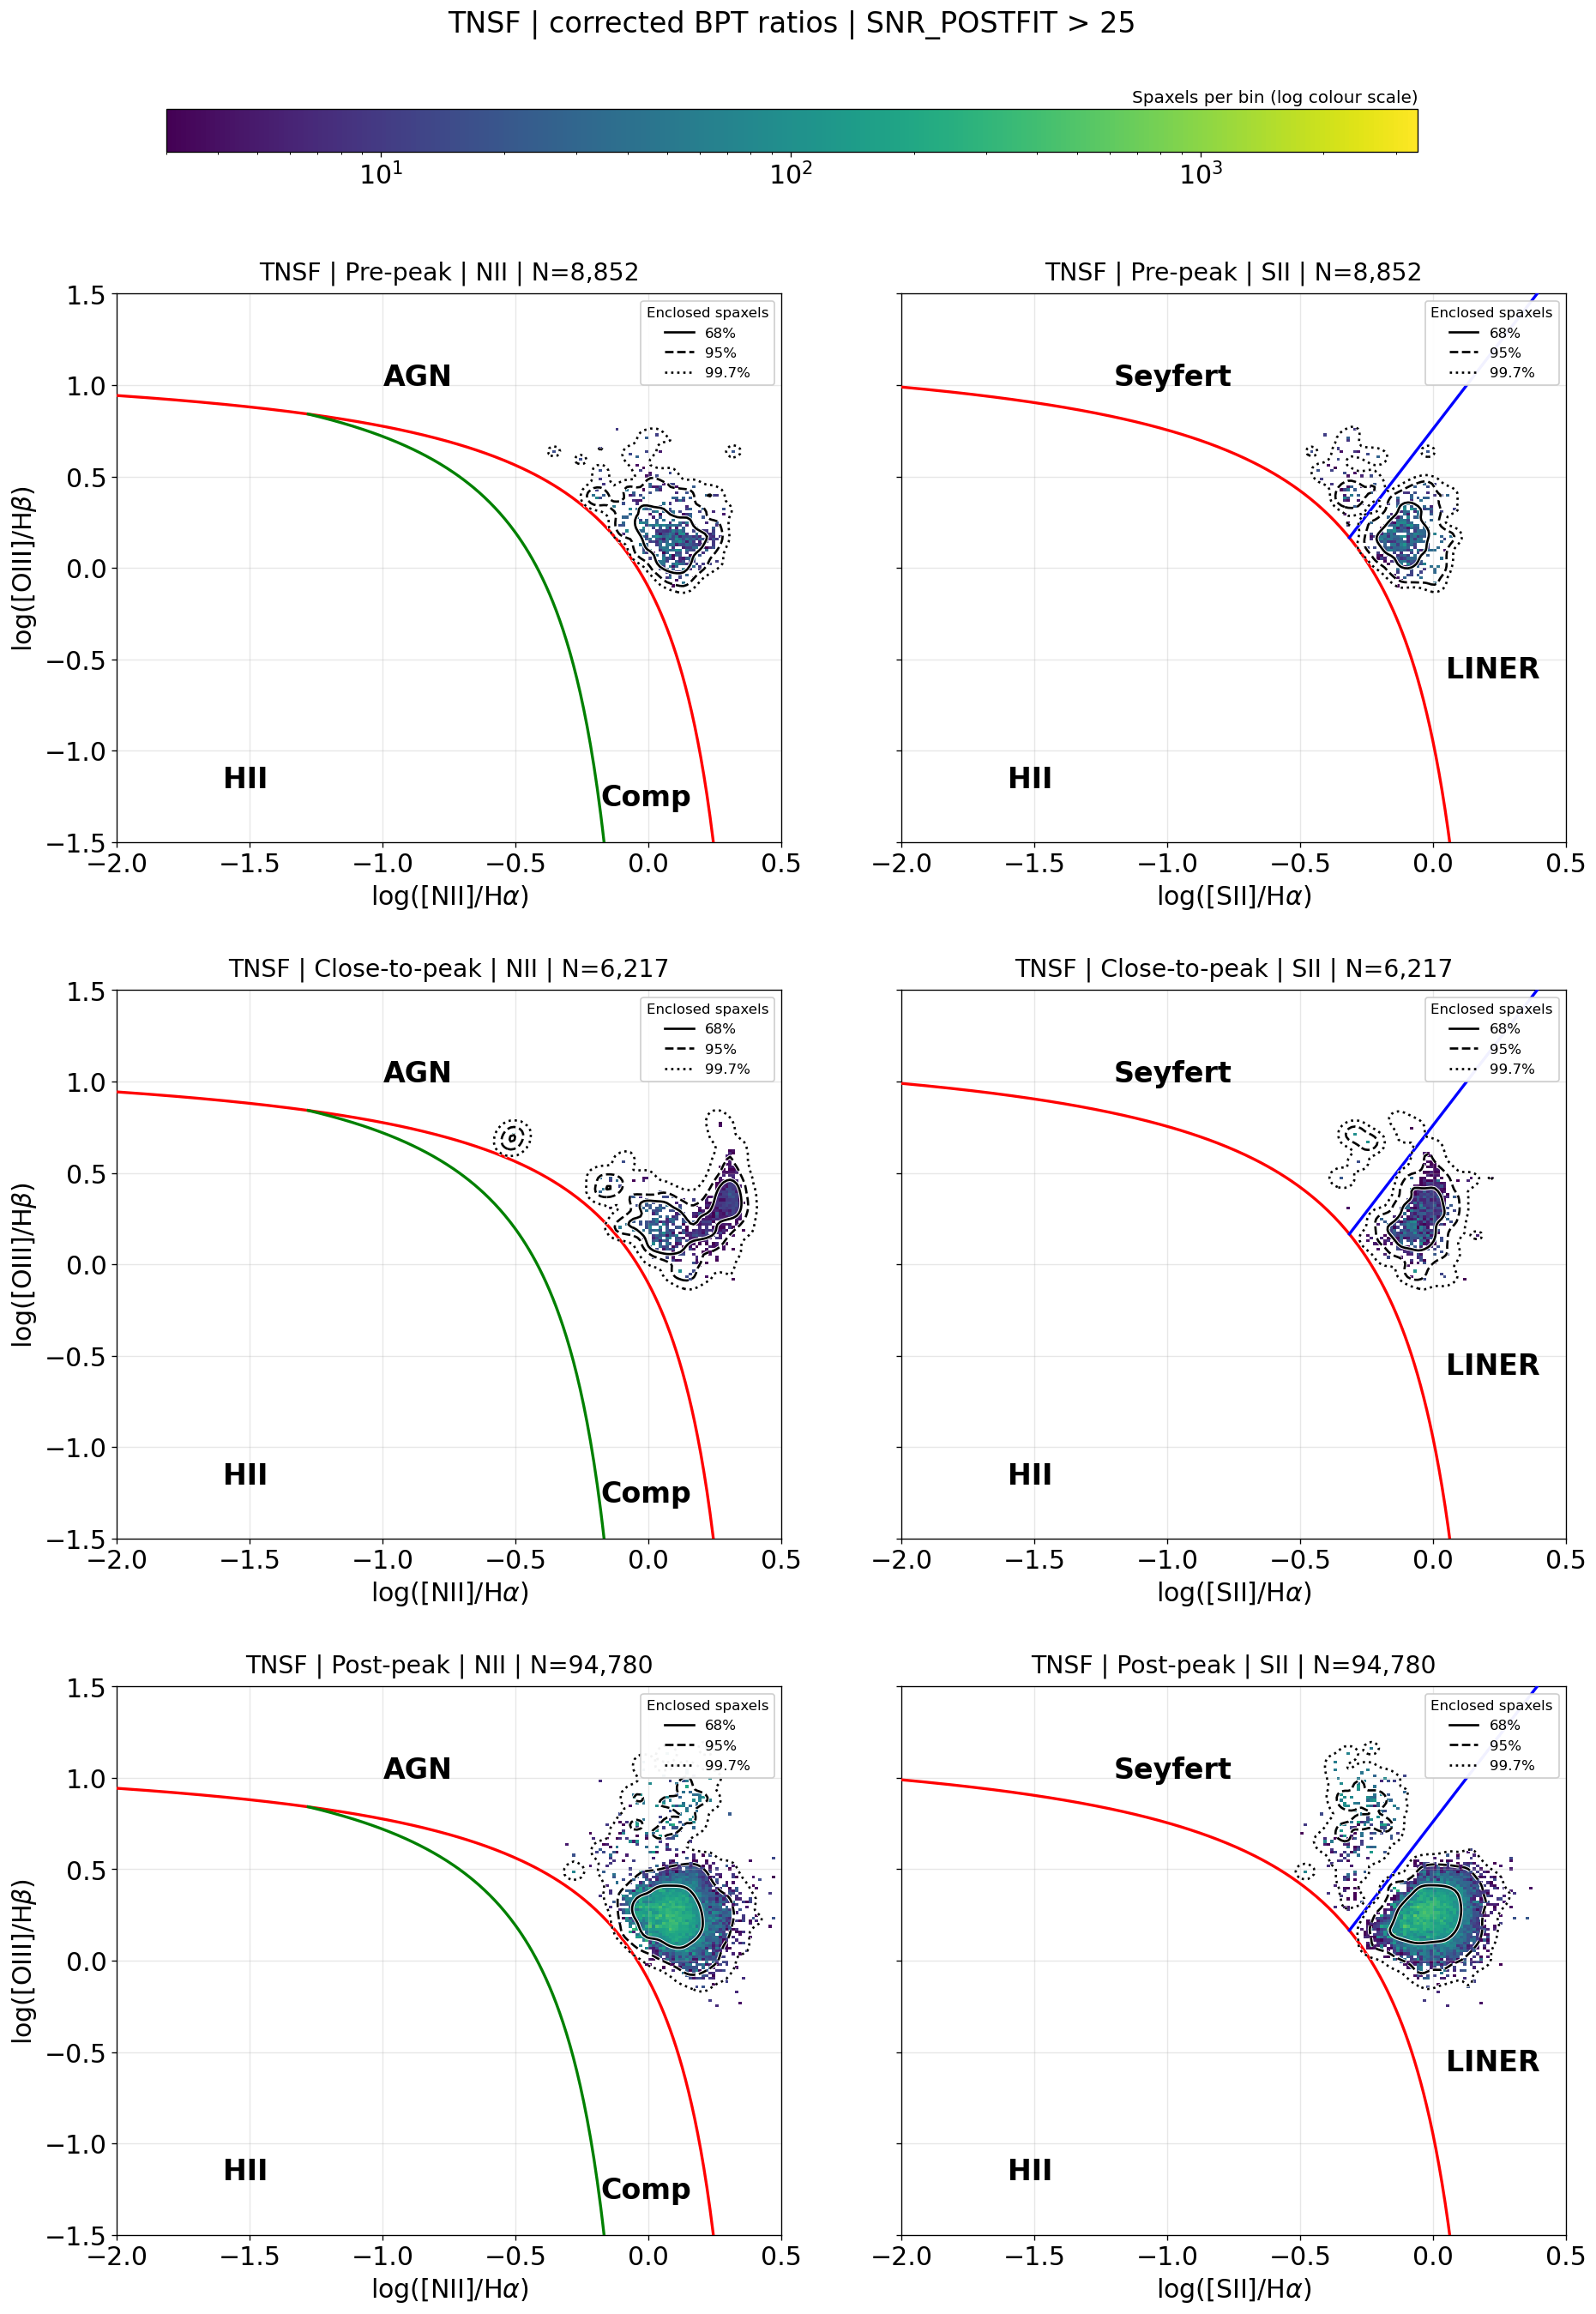

In [9]:
plot_catalogue_bpt('TNSF')


## SF + EW(Halpha)>20

Pre-peak, close-to-peak, post-peak rows; NII and SII columns.


SF + EW(Halpha)>20 | Pre-peak | NII: selected=788,098; paired=788,098; unavailable=0; galaxies=8
SF + EW(Halpha)>20 | Pre-peak | NII: paired=788,098; inside window=787,248; outside window=850; hidden in bins <3=183
SF + EW(Halpha)>20 | Pre-peak | NII: target=68%; enclosed bin-count fraction=68.0047%
SF + EW(Halpha)>20 | Pre-peak | NII: target=95%; enclosed bin-count fraction=95.0047%
SF + EW(Halpha)>20 | Pre-peak | NII: target=99.7%; enclosed bin-count fraction=99.7008%
SF + EW(Halpha)>20 | Pre-peak | SII: selected=788,098; paired=788,098; unavailable=0; galaxies=8
SF + EW(Halpha)>20 | Pre-peak | SII: paired=788,098; inside window=787,248; outside window=850; hidden in bins <3=454
SF + EW(Halpha)>20 | Pre-peak | SII: target=68%; enclosed bin-count fraction=68.0093%
SF + EW(Halpha)>20 | Pre-peak | SII: target=95%; enclosed bin-count fraction=95.0002%
SF + EW(Halpha)>20 | Pre-peak | SII: target=99.7%; enclosed bin-count fraction=99.7008%
SF + EW(Halpha)>20 | Close-to-peak | NII: selected

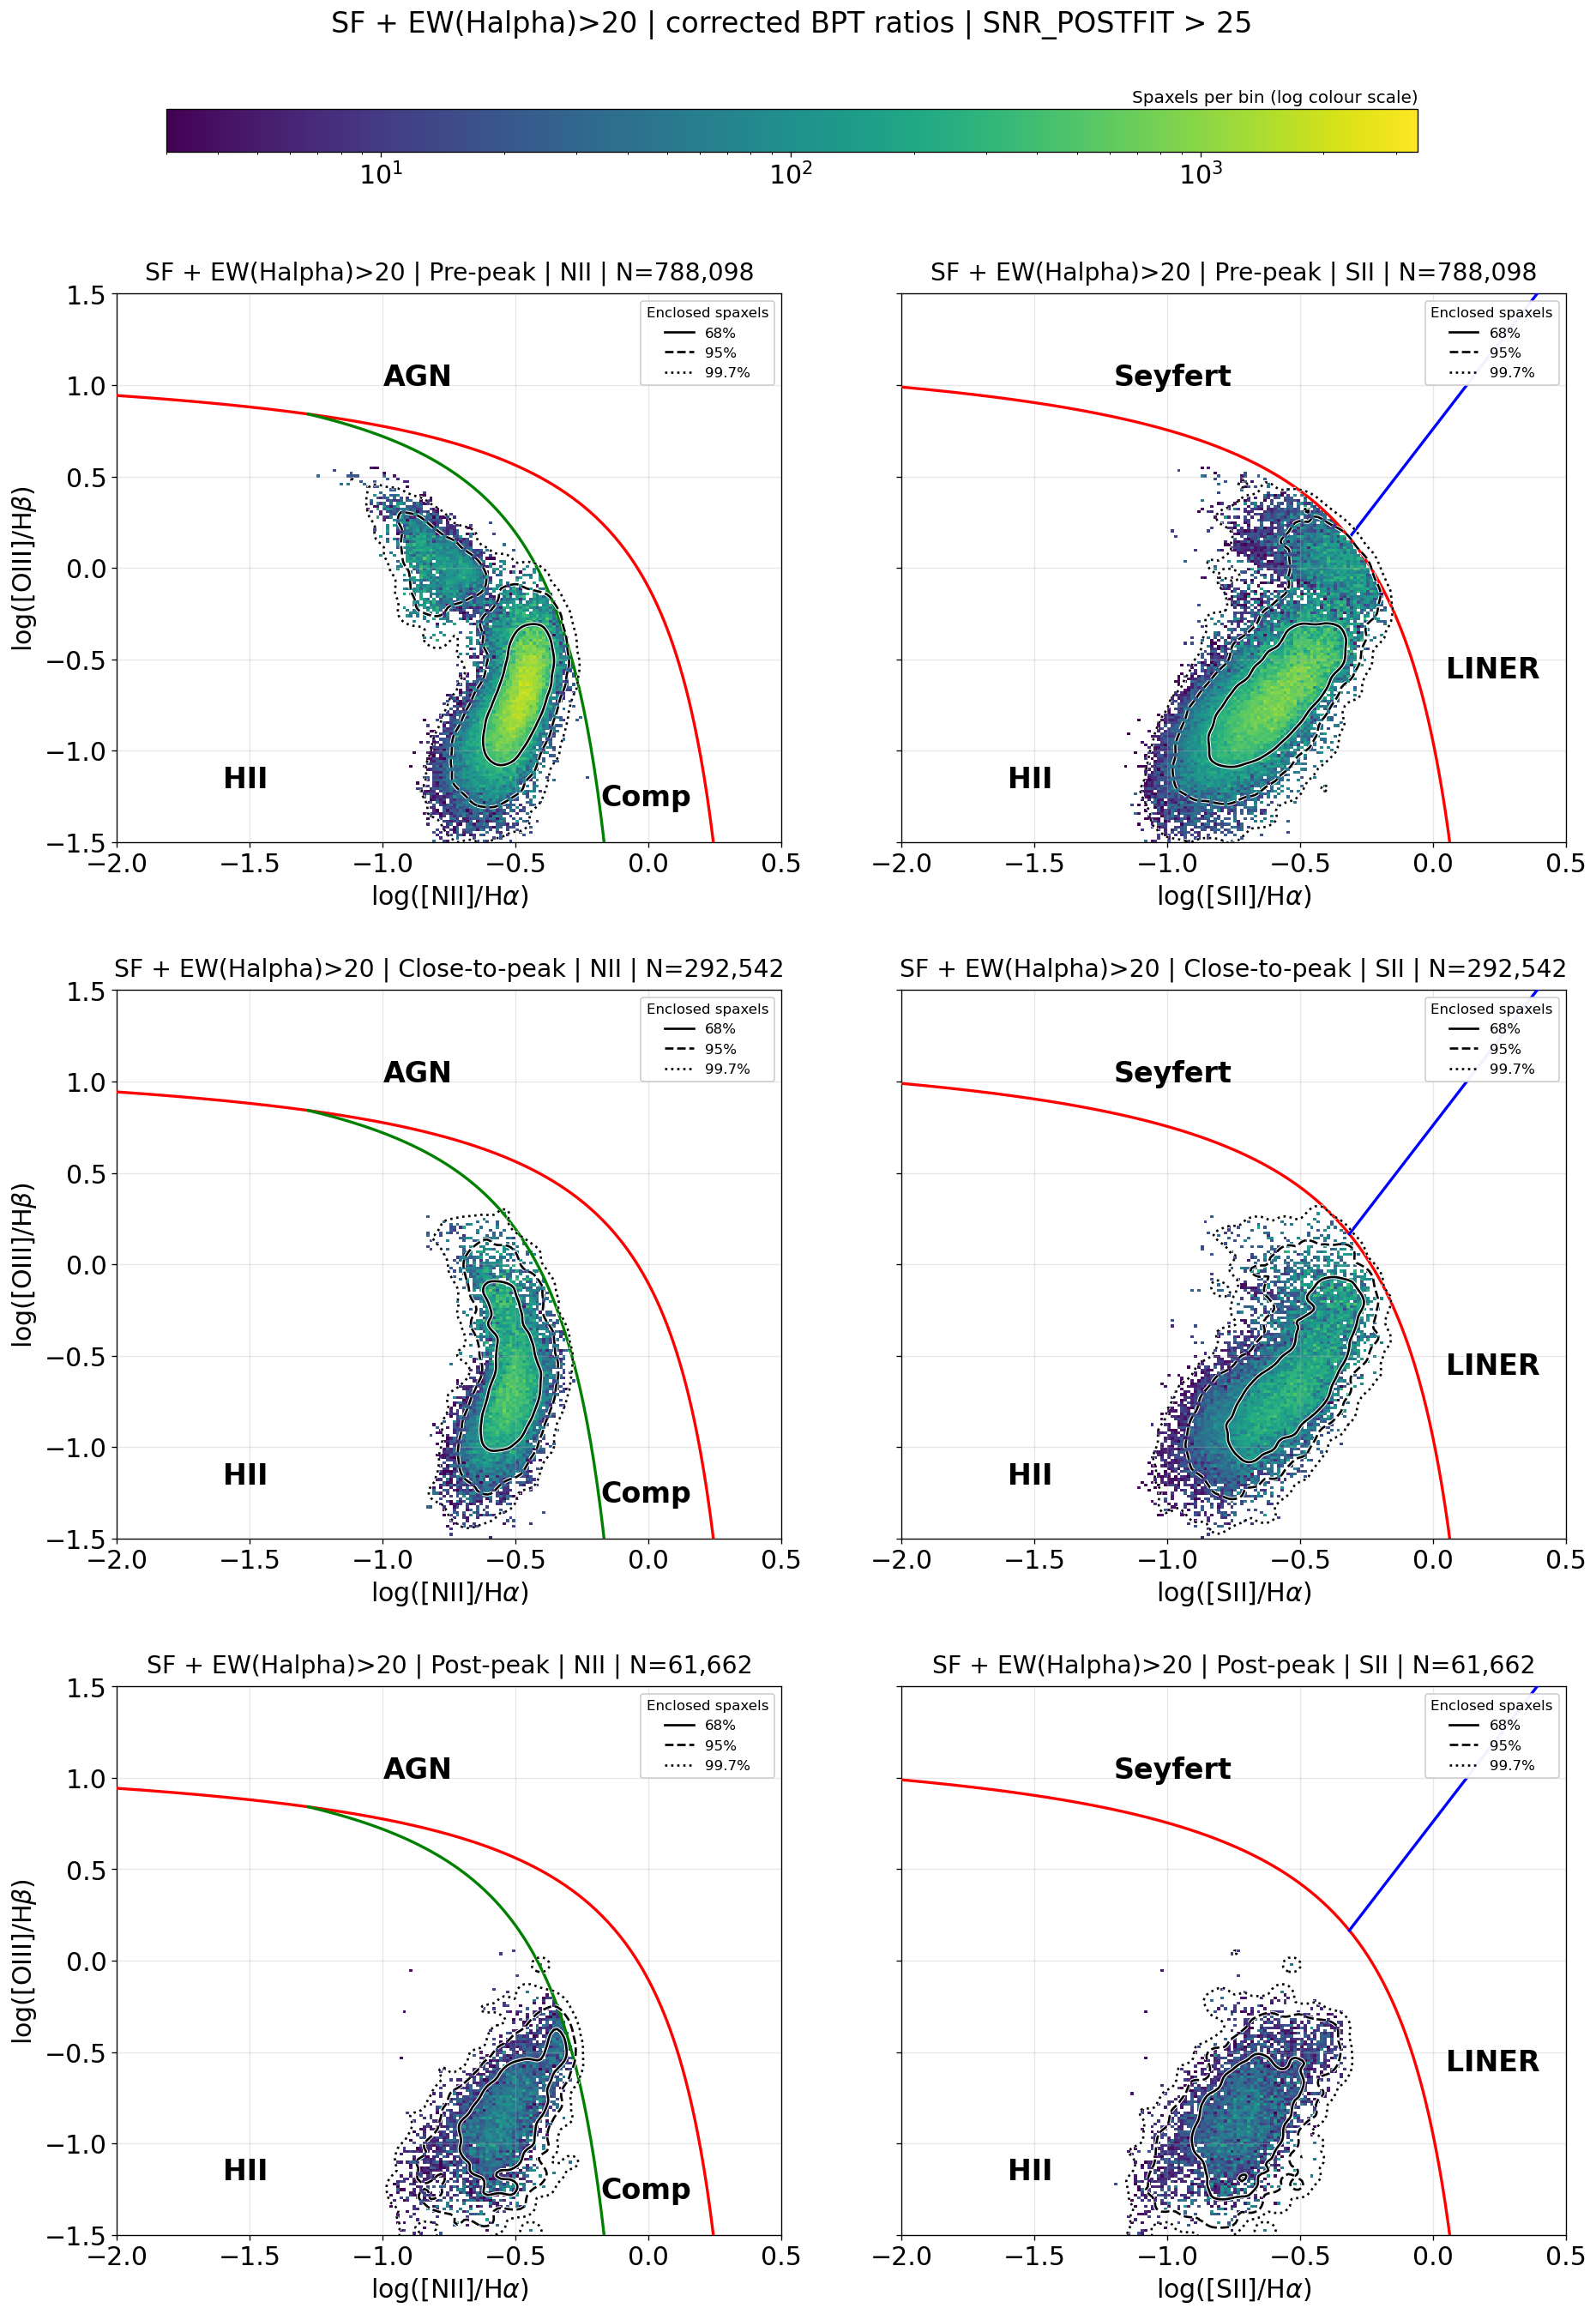

In [10]:
plot_catalogue_bpt('SF + EW(Halpha)>20')


## NSF + EW(Halpha)<3

Pre-peak, close-to-peak, post-peak rows; NII and SII columns.


NSF + EW(Halpha)<3 | Pre-peak | NII: selected=130,723; paired=130,238; unavailable=485; galaxies=5
NSF + EW(Halpha)<3 | Pre-peak | NII: paired=130,238; inside window=130,159; outside window=79; hidden in bins <3=22
NSF + EW(Halpha)<3 | Pre-peak | NII: target=68%; enclosed bin-count fraction=68.0508%
NSF + EW(Halpha)<3 | Pre-peak | NII: target=95%; enclosed bin-count fraction=95.0038%
NSF + EW(Halpha)<3 | Pre-peak | NII: target=99.7%; enclosed bin-count fraction=99.7059%
NSF + EW(Halpha)<3 | Pre-peak | SII: selected=130,723; paired=130,225; unavailable=498; galaxies=5
NSF + EW(Halpha)<3 | Pre-peak | SII: paired=130,225; inside window=130,146; outside window=79; hidden in bins <3=40
NSF + EW(Halpha)<3 | Pre-peak | SII: target=68%; enclosed bin-count fraction=68.0307%
NSF + EW(Halpha)<3 | Pre-peak | SII: target=95%; enclosed bin-count fraction=95.0056%
NSF + EW(Halpha)<3 | Pre-peak | SII: target=99.7%; enclosed bin-count fraction=99.7021%
NSF + EW(Halpha)<3 | Close-to-peak | NII: selected

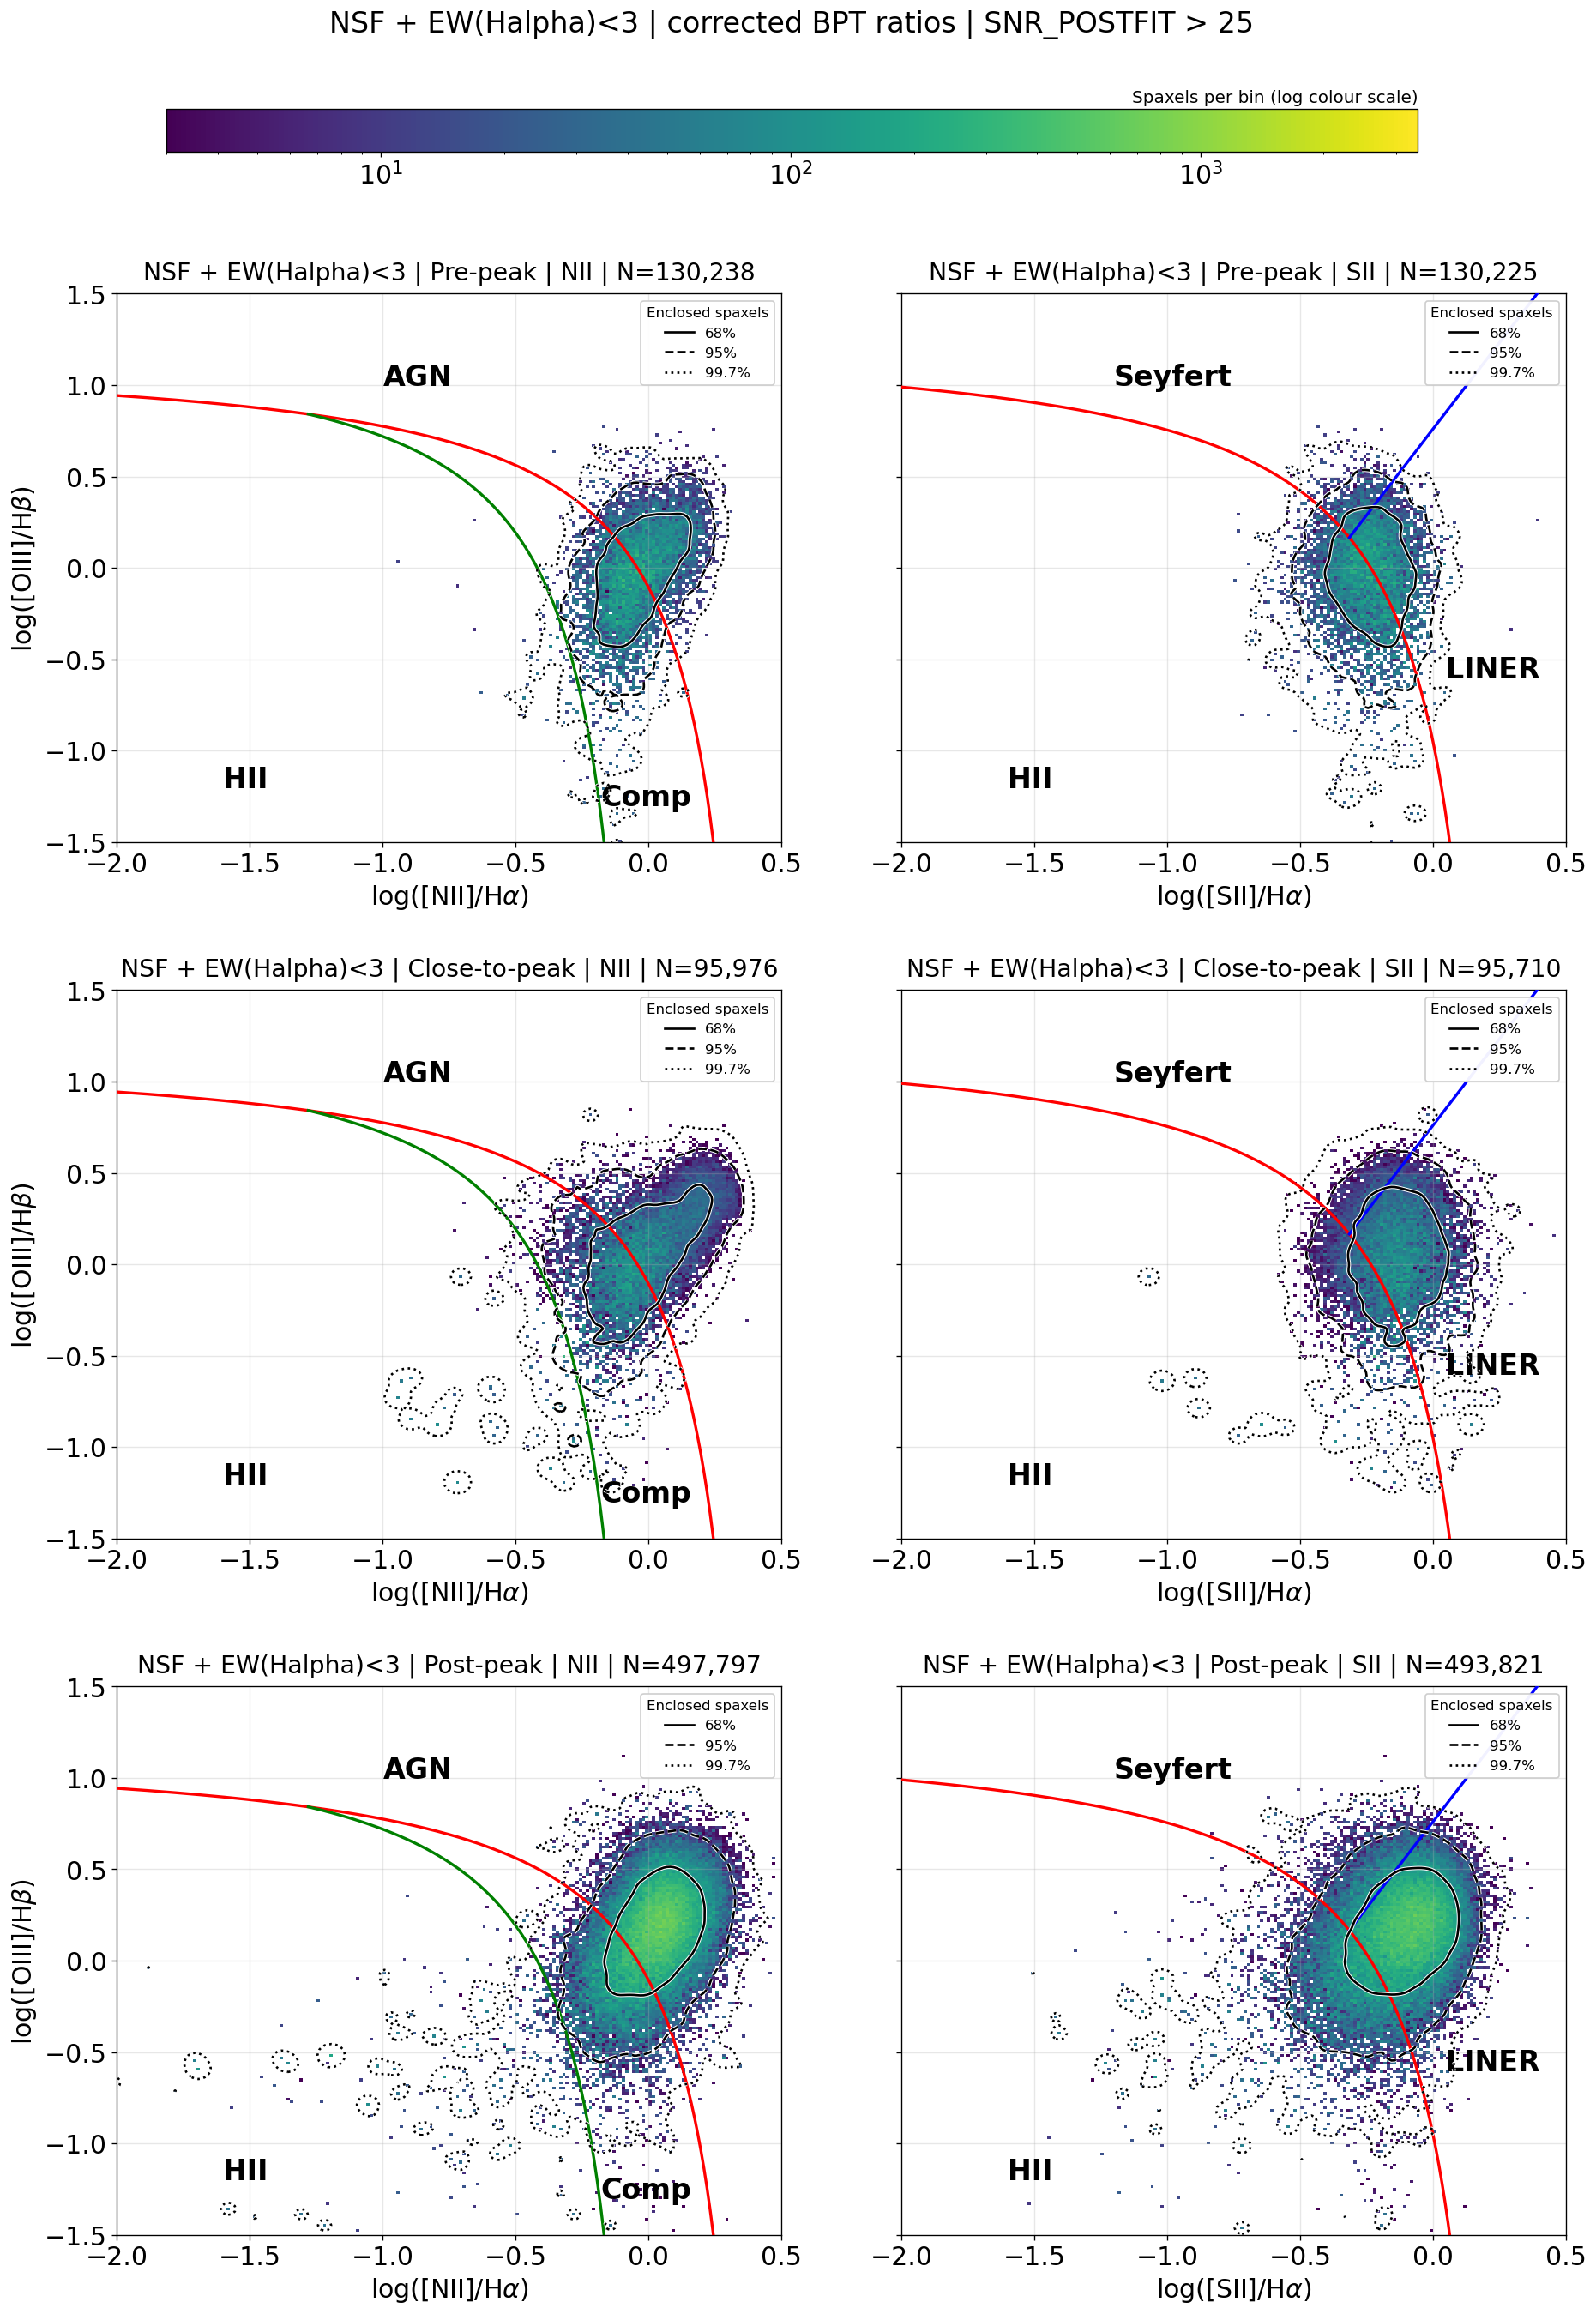

In [11]:
plot_catalogue_bpt('NSF + EW(Halpha)<3')


## TNSF + EW(Halpha)<3

Pre-peak, close-to-peak, post-peak rows; NII and SII columns.


TNSF + EW(Halpha)<3 | Pre-peak | NII: selected=2,702; paired=2,702; unavailable=0; galaxies=4
TNSF + EW(Halpha)<3 | Pre-peak | NII: paired=2,702; inside window=2,702; outside window=0; hidden in bins <3=0
TNSF + EW(Halpha)<3 | Pre-peak | NII: target=68%; enclosed bin-count fraction=68.0237%
TNSF + EW(Halpha)<3 | Pre-peak | NII: target=95%; enclosed bin-count fraction=95.3738%
TNSF + EW(Halpha)<3 | Pre-peak | NII: target=99.7%; enclosed bin-count fraction=99.8520%
TNSF + EW(Halpha)<3 | Pre-peak | SII: selected=2,702; paired=2,702; unavailable=0; galaxies=4
TNSF + EW(Halpha)<3 | Pre-peak | SII: paired=2,702; inside window=2,702; outside window=0; hidden in bins <3=0
TNSF + EW(Halpha)<3 | Pre-peak | SII: target=68%; enclosed bin-count fraction=68.1347%
TNSF + EW(Halpha)<3 | Pre-peak | SII: target=95%; enclosed bin-count fraction=95.0407%
TNSF + EW(Halpha)<3 | Pre-peak | SII: target=99.7%; enclosed bin-count fraction=99.8520%
TNSF + EW(Halpha)<3 | Close-to-peak | NII: selected=4,187; paire

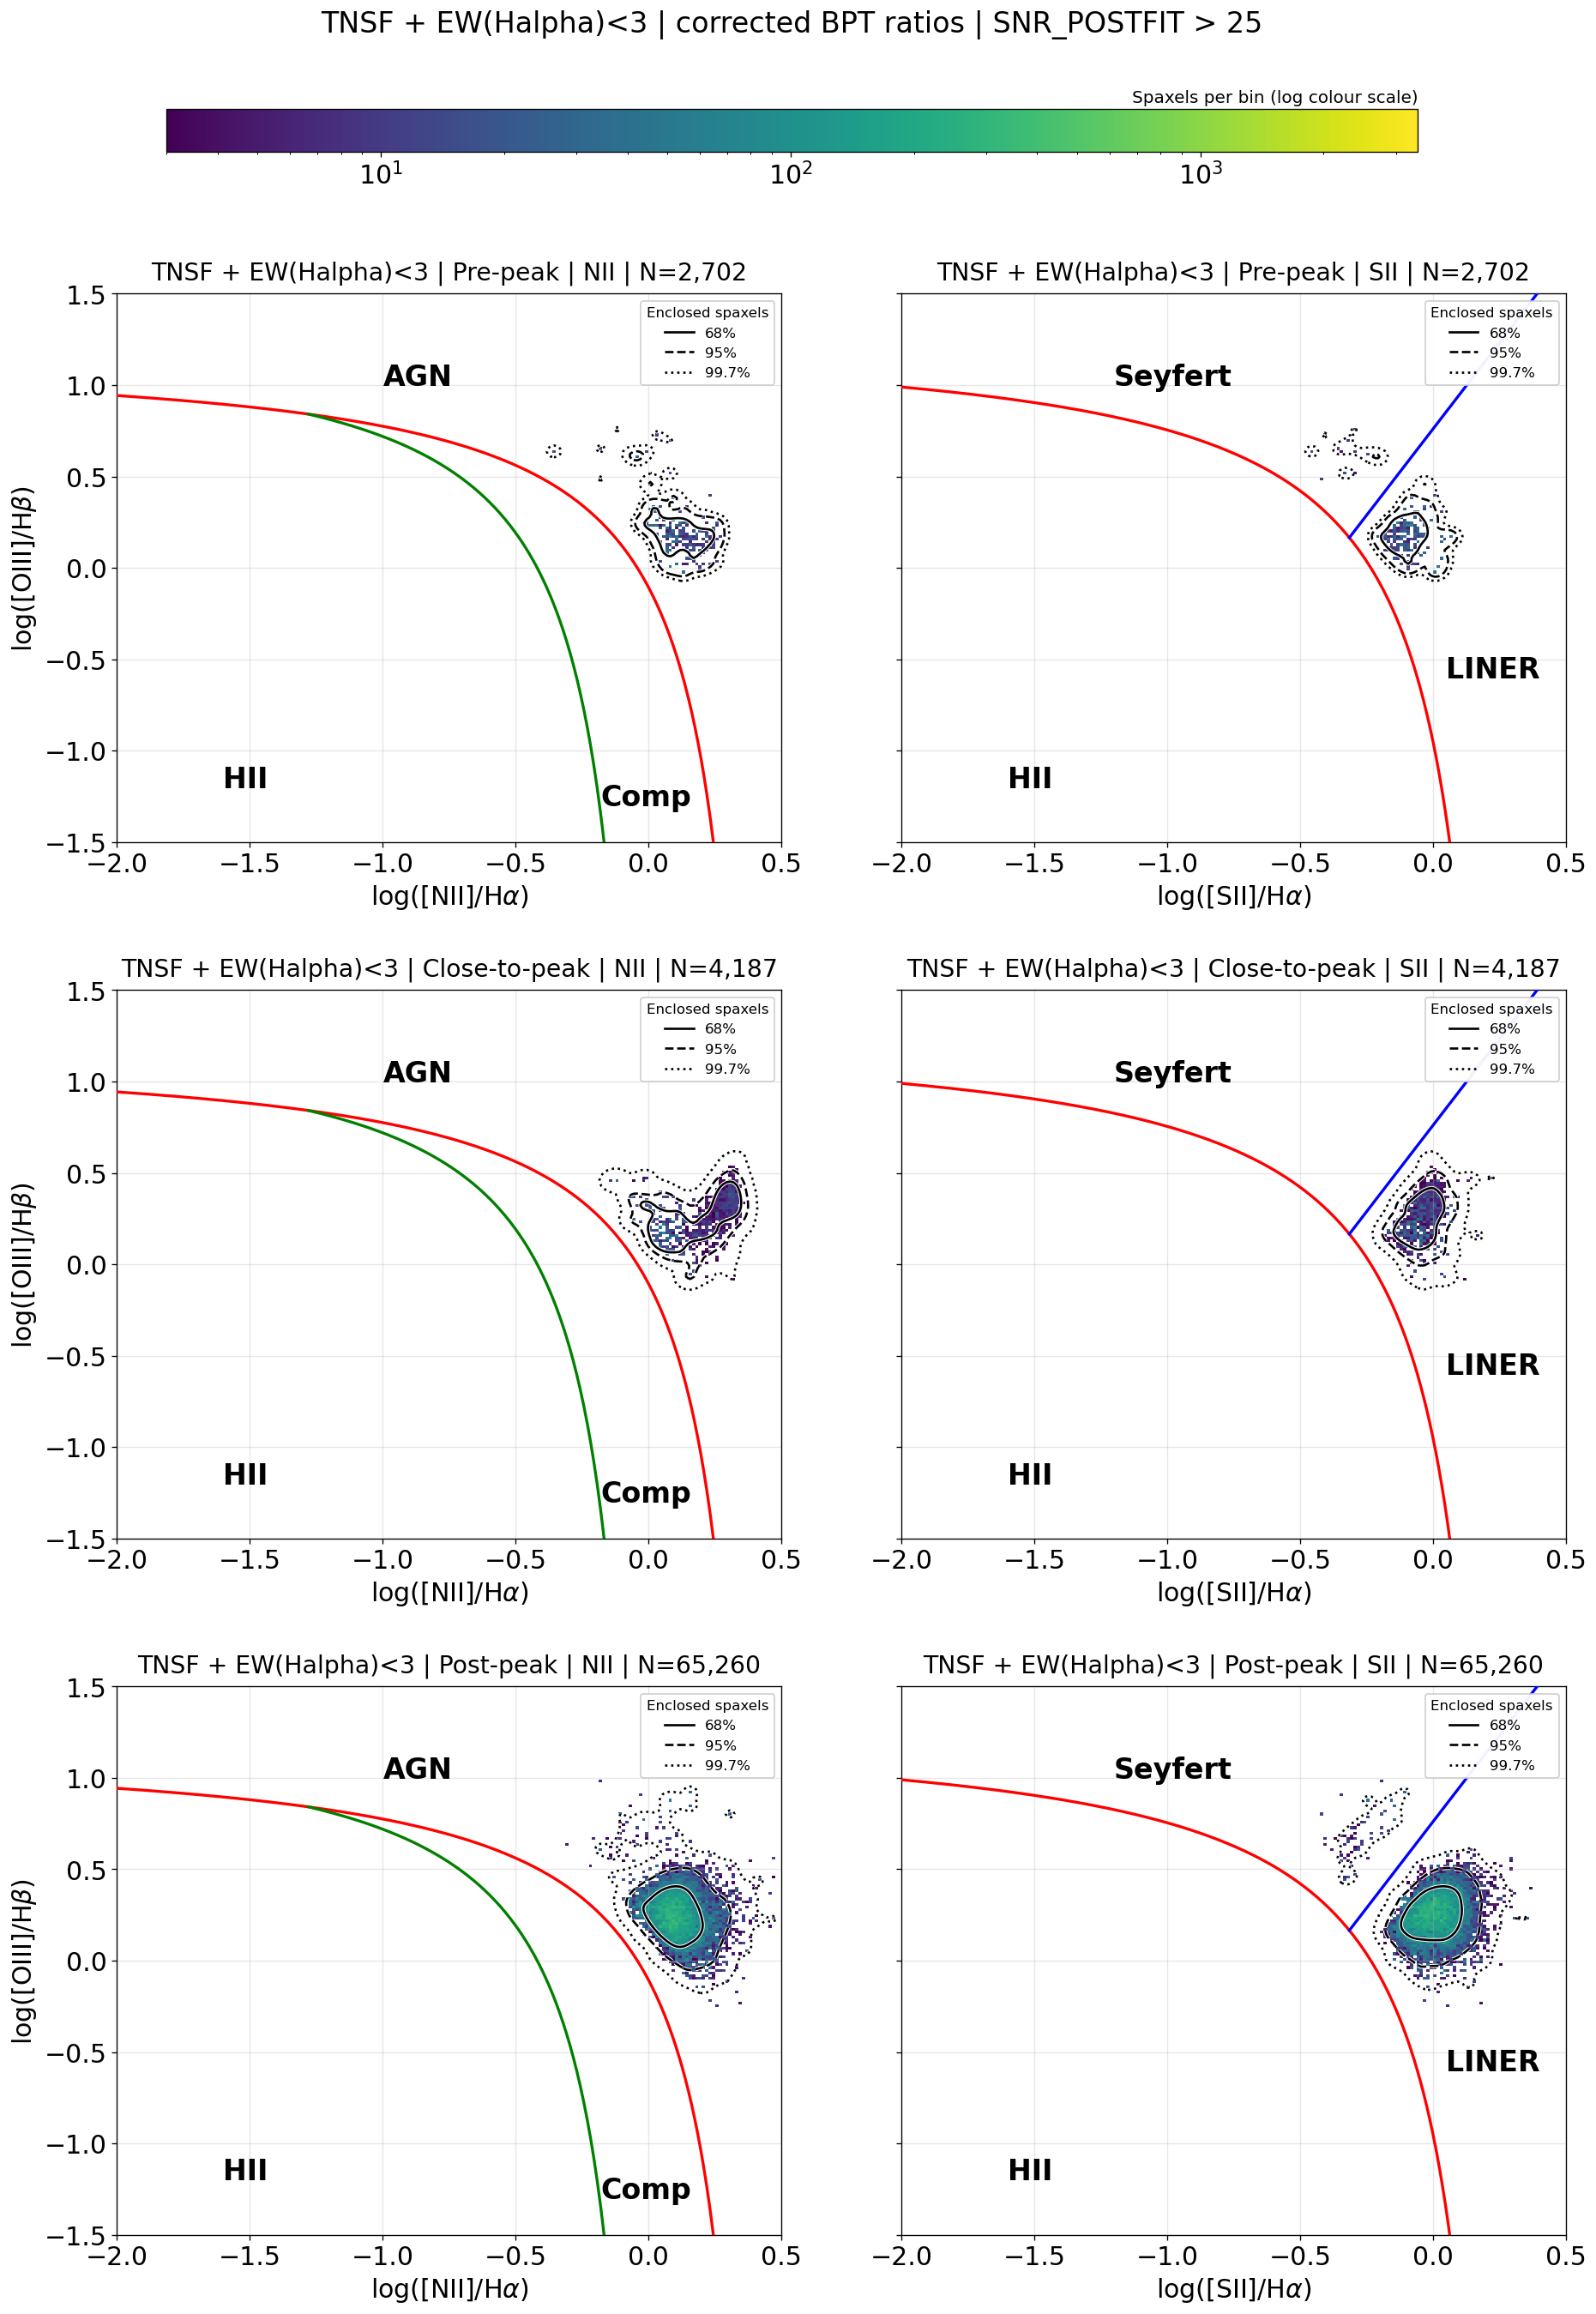

In [12]:
plot_catalogue_bpt('TNSF + EW(Halpha)<3')


## Count, contour and plotting checks


In [13]:
assert (BPT_COUNTS.N_paired + BPT_COUNTS.N_unavailable).eq(BPT_COUNTS.N_selected).all()
assert not BPT_COUNTS.duplicated(["GALID", "category", "diagram"]).any()
assert CATALOGUE_PLOT_IDS == list(CATEGORY_ORDER)
assert set(r["GALID"] for r in BPT_BY_GALAXY) == set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
assert len(BPT_BY_GALAXY) == len(CATEGORY_ORDER) * SAMPLE_QC.QC_flag.eq("OK").sum()
assert len(BPT_PLOT_CHECKS) == len(CATEGORY_ORDER) * len(STAGE_ORDER) * len(DIAGRAMS)
assert all(BPT_PLOT_CHECKS)
for category in CATEGORY_ORDER:
    for stage in STAGE_ORDER:
        for diagram in DIAGRAMS:
            expected = BPT_COUNTS.loc[BPT_COUNTS.category.eq(category) & BPT_COUNTS.stage.eq(stage)
                                      & BPT_COUNTS.diagram.eq(diagram), "N_paired"].sum()
            assert len(STAGE_PAIRS[category, stage, diagram]) == expected
BPT_WINDOW_COUNTS = pd.DataFrame(BPT_WINDOW_ROWS)
assert BPT_WINDOW_COUNTS.N_paired.eq(BPT_WINDOW_COUNTS.N_inside + BPT_WINDOW_COUNTS.N_outside).all()
display(BPT_WINDOW_COUNTS)
display(BPT_COUNTS.groupby(["category", "stage", "diagram"])[
    ["N_selected", "N_paired", "N_unavailable", "N_gas_bins"]].sum())
POPULATION_CONTOUR_SUMMARY = pd.DataFrame(POPULATION_CONTOUR_ROWS)
assert len(POPULATION_CONTOUR_SUMMARY) == len(CONTOUR_FRACTIONS) * int(BPT_WINDOW_COUNTS.N_paired.gt(0).sum())
assert (POPULATION_CONTOUR_SUMMARY.enclosed_fraction + 1e-12 >= POPULATION_CONTOUR_SUMMARY.fraction).all()
assert (POPULATION_CONTOUR_SUMMARY.fraction_above_tie <= POPULATION_CONTOUR_SUMMARY.fraction + 1e-12).all()
for _, panel in POPULATION_CONTOUR_SUMMARY.groupby(['panel', 'diagram']):
    ordered = panel.sort_values('fraction')
    assert (np.diff(ordered.enclosed_fraction) >= -1e-12).all()
    assert (np.diff(ordered.threshold) <= 1e-12).all()
display(POPULATION_CONTOUR_SUMMARY)
print('POPULATION_CONTOURS_VALIDATION_OK: full-population count calibration; 68/95/99.7 percent contours')
print('SIX_CATALOGUE_BPT_VALIDATION_OK: six 3x2 stage figures; 36 panels; shared raw-count colour scale')


,panel,diagram,N_paired,N_inside,N_outside,N_hidden_low_count
0,SF | Pre-peak,NII,1420915,1418389,2526,188
1,SF | Pre-peak,SII,1420915,1418389,2526,466
2,SF | Close-to-peak,NII,720842,720447,395,161
3,SF | Close-to-peak,SII,720842,720447,395,304
4,SF | Post-peak,NII,222427,220561,1866,53
5,SF | Post-peak,SII,222427,220561,1866,141
6,NSF | Pre-peak,NII,923230,922677,553,561
7,NSF | Pre-peak,SII,923217,922664,553,1054
8,NSF | Close-to-peak,NII,486897,486658,239,1124
9,NSF | Close-to-peak,SII,486631,486320,311,1015


N_selected  N_paired  \
category            stage         diagram                         
NSF                 close-to-peak NII          488865    486897   
                                  SII          488865    486631   
                    post-peak     NII          815887    810973   
                                  SII          815887    806315   
                    pre-peak      NII          929104    923230   
                                  SII          929104    923217   
NSF + EW(Halpha)<3  close-to-peak NII           97038     95976   
                                  SII           97038     95710   
                    post-peak     NII          500179    497797   
                                  SII          500179    493821   
                    pre-peak      NII          130723    130238   
                                  SII          130723    130225   
SF                  close-to-peak NII          720842    720842   
                                  SII          720842    720842   
                    post-peak     NII          222427    222427   
                                  SII          222427    222427   
                    pre-peak      NII         1420915   1420915   
                                  SII         1420915   1420915   
SF + EW(Halpha)>20  close-to-peak NII          292542    292542   
                                  SII          292542    292542   
                    post-peak     NII           61662     61662   
                                  SII           61662     61662   
                    pre-peak      NII          788098    788098   
                                  SII          788098    788098   
TNSF                close-to-peak NII            6217      6217   
                                  SII            6217      6217   
                    post-peak     NII           94780     94780   
                                  SII           94780     94780   
                    pre-peak      NII            8852      8852   
                                  SII            8852      8852   
TNSF + EW(Halpha)<3 close-to-peak NII            4187      4187   
                                  SII            4187      4187   
                    post-peak     NII           65260     65260   
                                  SII           65260     65260   
                    pre-peak      NII            2702      2702   
                                  SII            2702      2702   

                                           N_unavailable  N_gas_bins  
category            stage         diagram                             
NSF                 close-to-peak NII               1968       55574  
                                  SII               2234       55556  
                    post-peak     NII               4914      129673  
                                  SII               9572      129346  
                    pre-peak      NII               5874       53651  
                                  SII               5887       53650  
NSF + EW(Halpha)<3  close-to-peak NII               1062       22720  
                                  SII               1328       22702  
                    post-peak     NII               2382       90127  
                                  SII               6358       89807  
                    pre-peak      NII                485        8671  
                                  SII                498        8670  
SF                  close-to-peak NII                  0       56923  
                                  SII                  0       56923  
                    post-peak     NII                  0       23182  
                                  SII                  0       23182  
                    pre-peak      NII                  0       89280  
                                  SII                  0       89280  
SF + EW(Halpha)>20  close-to-peak NII                  0       21181  
     

,panel,diagram,N_paired,fraction,threshold,enclosed_fraction,fraction_above_tie
0,SF | Pre-peak,NII,1420915,0.680,702.993304,0.680229,0.679791
1,SF | Pre-peak,NII,1420915,0.950,73.437076,0.950122,0.949977
2,SF | Pre-peak,NII,1420915,0.997,6.217011,0.997001,0.996999
3,SF | Pre-peak,SII,1420915,0.680,385.661164,0.680153,0.679755
4,SF | Pre-peak,SII,1420915,0.950,60.908080,0.950027,0.949975
...,...,...,...,...,...,...,...
103,TNSF + EW(Halpha)<3 | Post-peak,NII,65260,0.950,13.243831,0.950107,0.949740
104,TNSF + EW(Halpha)<3 | Post-peak,NII,65260,0.997,0.696569,0.997119,0.996905
105,TNSF + EW(Halpha)<3 | Post-peak,SII,65260,0.680,85.694276,0.680064,0.678992
106,TNSF + EW(Halpha)<3 | Post-peak,SII,65260,0.950,13.714837,0.950000,0.949663


POPULATION_CONTOURS_VALIDATION_OK: full-population count calibration; 68/95/99.7 percent contours
SIX_CATALOGUE_BPT_VALIDATION_OK: six 3x2 stage figures; 36 panels; shared raw-count colour scale
